<a href="https://colab.research.google.com/github/Micosz/CS240_Dataset_Uboat/blob/main/Main_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **สมาชิกในกลุ่มและหน้าที่รับผิดชอบ** ##


---


1. **6709650037 ทีปรกร รักแฟ้น** `Data Preparation`
2. **6709650383 ธนวัฒน์ กุลพันธ์** `Data Preparation`
3. **6709650573 ภูรินทร์ แก้วพ่วงเสก** `Data Preparation`
4. **6709650235 ชนกานต์ คงรัชตภิญโญ** `Visualization & Interpretation`
5. **6709650490 พรปวีณ์ แสนทวีสุข** `Visualization & Interpretation`
6. **6709650227 ชญานินท์ เจียมเจริญ**  `Visualization & Interpretation`
8. **6709650631 ศิริมงคล ดอนศรีโคตร**  `Model Building`
9. **6709650680 สหรัฐ อุดมวัฒน์ทวี**  `Model Building`
10. **6709650193 จรัสรวี วศินธรากร**  `Model Building`

#**Problem Framing**



---






ปัจจัยทางโครงสร้างและการปฏิบัติการของเรือดำน้ำเยอรมันในช่วงสงครามโลก มีอิทธิพลต่อโอกาสการจมหรืออยู่รอดของเรือหรือไม่

# **Data Acquisition**


---


ข้อมูล Dataset นี้เป็นข้อมูลที่มีเเหล่งที่มาจากเว็บไซต์ Kaggle : https://www.kaggle.com/datasets/cormac42/ww2-u-boats

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import seaborn as sns
from matplotlib import font_manager

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

from sklearn.inspection import permutation_importance

สำหรับรายละเอียดการ Import ต่างๆ คือ

`import re`
ใช้สำหรับเพื่อค้นหาและจัดรูปแบบข้อความในข้อมูล เช่น การลบสัญลักษณ์หรือการแยกคำเฉพาะในขั้นตอน Data Cleaning

`import numpy as np`
ไลบรารีพื้นฐานสำหรับการคำนวณ เช่น การจัดการ array, matrix และการคำนวณเชิงตัวเลข

`import pandas as pd`
ใช้ในการจัดการ DataFrame โดยถูกนำมาใช้ในทั้งสามส่วนของ Data Acquisition, Data Preparation เเละ Data Cleansing

`import matplotlib.pyplot as plt`
สำหรับการสร้างกราฟพื้นฐานเพื่อช่วยในการวิเคราะห์ข้อมูล

`import seaborn as sb, sns`
ใช้สำหรับสร้าง Data Visualization เพื่อแสดงการกระจายและความสัมพันธ์ของข้อมูล

`from sklearn.preprocessing import LabelEncoder`
ใช้ในขั้นตอน Data Preparation เพื่อแปลงค่าข้อมูลที่เป็นข้อความหรือหมวดหมู่ ให้เป็นข้อมูล numerical data เช่น Ship_Type, Fate_Event

`from sklearn.preprocessing import StandardScaler`
ใช้สำหรับการปรับข้อมูลตัวเลขให้อยู่ในมาตรฐานเดียวกัน โดยมีค่าเฉลี่ย = 0 และส่วนเบี่ยงเบนมาตรฐาน = 1 เพื่อช่วยให้โมเดลเรียนรู้ได้มีประสิทธิภาพมากขึ้น

`from sklearn.model_selection import train_test_split`
ใช้ในการแบ่งชุดข้อมูลทั้งหมดออกเป็น 2 ส่วน คือ ชุดฝึกหรือ Training set และ ชุดทดสอบ หรือ Testing set

`from sklearn.model_selection import StratifiedKFold`
ใช้สำหรับการแบ่งข้อมูลแบบ cross-validation โดยคงสัดส่วนของ class แต่ละกลุ่มให้เท่ากันในแต่ละรอบ

`from sklearn.model_selection import cross_val_score`
 ใช้ในการประเมินความแม่นยำของโมเดลโดยการทดสอบซ้ำและหาค่าเฉลี่ย

`from sklearn.linear_model import LogisticRegression`
ใช้สร้างโมเดล Logistic Regression สำหรับการจำแนกข้อมูลแบบ Binary เช่น การทำนายว่าเรือ “จม” หรือ “รอด”

`from sklearn.tree import DecisionTreeClassifier`
ใช้สร้างโมเดล Decision Tree

`from sklearn.tree import plot_tree`
ใช้สำหรับวาดแผนภาพของโมเดล Decision Tree

`from sklearn.ensemble import RandomForestClassifier`
ใช้สร้างโมเดลแบบ Random Forest

`from sklearn.neighbors import KNeighborsClassifier`
ใช้สร้างโมเดล K-Nearest Neighbors

`from sklearn.discriminant_analysis import LinearDiscriminantAnalysis`
ใช้สร้างโมเดล Linear Discriminant Analysis

`from sklearn.naive_bayes import GaussianNB`
ใช้สร้างโมเดล Naive Bayes แบบ Gaussian

`from sklearn.svm import SVC`
ใช้สร้างโมเดล Support Vector Machine

`from sklearn.metrics import accuracy_score`
ใช้วัดความแม่นยำของโมเดล โดยคำนวณจากสัดส่วนของการทำนายที่ถูกต้องทั้งหมด

`from sklearn.metrics import precision_score`
ใช้วัดความแม่นยำของการทำนายจากจำนวนที่โมเดลทำนายว่าเป็นกลุ่มเป้าหมายทั้งหมด
มีจำนวนเท่าไรที่ ทำนายถูก

`from sklearn.metrics import recall_score`
ใช้วัดความครอบคลุมว่าจากจำนวนทั้งหมดที่จมเป็นจริง
โมเดลสามารถจับได้ถูกต้องกี่เปอร์เซ็นต์

`from sklearn.metrics import f1_score`
ใช้วัดสมดุลระหว่าง precision และ recall

`from sklearn.metrics import classification_report`
ใช้สร้างรายงานสรุปผลการทำนายของโมเดล เช่น accuracy, precision, recall, และ f1-score สำหรับแต่ละ class

`from sklearn.metrics import confusion_matrix`
ใช้สร้าง Confusion Matrix

`from sklearn.metrics import roc_auc_score`
ใช้วัดค่า Area Under Curve

##ขั้นตอนที่ 1 : การดึงข้อมูลด้วย pandas





In [ ]:
#เชื่อม Colab เข้ากับ Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#นำ Dataset มาใส่ใน uboat_data
uboat_data = pd.read_csv('/content/drive/MyDrive/uboats.csv')

In [ ]:
uboat_data.shape

(1153, 26)

พบว่า dataset มี 1153 เเถว มีเรือดำน้ำทั้งหมด 1,152 ลำ โดยแต่ละลำมีรายละเอียดข้อมูลทั้งหมด 26 ข้อมูล

---

##ขั้นตอนที่ 2 : การแสดงรายละเอียดข้อมูล


In [ ]:
display(uboat_data.head())

,Name,Year,Type,Notable Commanders,Warships_sunk_n_total_loss_No,Warships_sunk_n_total_loss_Tons-n-GRT,Warships_Damaged_No,Warships_Damaged_Tons-n-GRT,Merchant_Ships_sunk_No,Merchant_Ships_sunk_GRT,...,Notes,URL,Commissioned,Patrols,Patrols_Count,Wolfpacks,Wolfpacks_Count,Flotilla,Flotilla_Count,Last_Flotilla
0,U-1,1935,IIA,Klaus Ewerth,0,0,0,0,0,0,...,Struck a mine,https://en.wikipedia.org/wiki/German_submarine...,1935-06-29,2 patrols:1st patrol:15 – 29 March 19402nd pat...,2,NaN,0,"{'U-boat School Flotilla': ['1 July 1935 ', ' ...",1,U-boat School Flotilla
1,U-2,1935,IIA,"Hans Heidtmann,Heinrich Liebe,Helmut Rosenbaum...",0,0,0,0,0,0,...,Training boat,https://en.wikipedia.org/wiki/German_submarine...,1935-07-25,2 patrols:1st patrol:15 – 29 March 19402nd pat...,2,NaN,0,"{'U-boat School Flotilla': ['1 July 1935 ', ' ...",2,21st U-boat Flotilla
2,U-3,1935,IIA,"Joachim Schepke,Otto von Bülow,Hans-Hartwig Tr...",0,0,0,0,2,"2,348",...,NaN,https://en.wikipedia.org/wiki/German_submarine...,1935-09-06,5 patrols:1st patrol:4 – 8 September 19392nd p...,5,NaN,0,"{'U-boat School Flotilla': ['1 August 1935 ', ...",2,21st U-boat Flotilla
3,U-4,1935,IIA,Heinz-Otto Schultze,1,"1,090",0,0,3,"5,133",...,NaN,https://en.wikipedia.org/wiki/German_submarine...,1935-08-17,4 patrols:1st patrol:4 – 14 September 19392nd ...,4,NaN,0,"{'U-boat School Flotilla': ['1 August 1935 ', ...",2,21st U-boat Flotilla
4,U-5,1935,IIA,Heinrich Lehmann-Willenbrock,0,0,0,0,0,0,...,Accident,https://en.wikipedia.org/wiki/German_submarine...,1935-08-31,2 patrols:1st patrol:24 August – 8 September 1...,2,NaN,0,{'U-boat School Flotilla': ['1 September 1935 ...,2,21st U-boat Flotilla


**โดยรายละเอียดของข้อมูลคือ**


Name: ชื่อเรือดำน้ำ (เช่น U-1, U-2)

Year: ปีที่สร้างเรือ

Type: ชนิดของเรือดำน้ำ (เช่น IIA, XXIII)

Notable Commanders: ชื่อผู้บังคับการที่โดดเด่น

Warships_sunk_n_total_loss_No: จำนวนเรือรบที่จมทั้งหมด

Warships_sunk_n_total_loss_Tons-n-GRT: น้ำหนักรวม (ตัน) ของเรือรบที่จม

Warships_Damaged_No: จำนวนเรือรบที่เสียหาย

Warships_Damaged_Tons-n-GRT: น้ำหนักรวม (ตัน) ของเรือรบที่เสียหาย

Merchant_Ships_sunk_No: จำนวนเรือสินค้าที่จมทั้งหมด

Merchant_Ships_sunk_GRT: น้ำหนักรวม (GRT) ของเรือสินค้าที่จม

Merchant_Ships_damaged_No: จำนวนเรือสินค้าที่เสียหาย

Merchant_Ships_damaged_GRT: น้ำหนักรวม (GRT) ของเรือสินค้าที่เสียหาย

Merchant_Ships_total_loss_No: จำนวนเรือสินค้าที่เสียหายจนใช้งานไม่ได้

Merchant_Ships_total_loss_GRT: น้ำหนักรวม (GRT) ของเรือสินค้าที่เสียหายจนใช้งานไม่ได้

Fate_Event: เหตุการณ์ที่เกิดขึ้นกับเรือ (เช่น ถูกจม, ยอมจำนน)

Fate_Date: วันที่เกิดเหตุการณ์

Notes: หมายเหตุเพิ่มเติม

URL: ลิงก์ไปยังข้อมูลเพิ่มเติม

Commissioned: วันที่ขึ้นระวาง

Patrols: ข้อมูลการลาดตระเวน

Patrols_Count: จำนวนครั้งในการลาดตระเวน

Wolfpacks: ข้อมูลของกลุ่มเรือดำน้ำ (Wolfpack) ที่เข้าร่วม

Wolfpacks_Count: จำนวนกลุ่ม Wolfpack ที่เข้าร่วม

Flotilla: กองเรือที่สังกัด

Flotilla_Count: จำนวนกองเรือที่สังกัด

Last_Flotilla: กองเรือสุดท้ายที่สังกัด

#**Data Preparation**


---



In [ ]:
# หาอัตราส่วน 100% ของเเต่ละ columns หากพบ null
missing_ratio = uboat_data.isnull().mean() * 100

# เรียงจากมากไปน้อยโดยค่าที่เเสดงต้องมีค่ามากกว่า 0
missing_ratio = missing_ratio[missing_ratio > 0].sort_values(ascending=False)

print(missing_ratio)

Notable Commanders    81.092801
Wolfpacks             67.562879
Patrols               25.672160
Notes                 21.682567
Fate_Date              0.260191
Commissioned           0.173461
dtype: float64


In [ ]:
#drop columns ที่ไม่ได้ใช้
cleaned_uboat = uboat_data.copy()
cleaned_uboat = cleaned_uboat.drop(['URL', 'Notes', 'Patrols', 'Flotilla','Wolfpacks', 'Commissioned'], axis=1)
cleaned_uboat.head(10)

,Name,Year,Type,Notable Commanders,Warships_sunk_n_total_loss_No,Warships_sunk_n_total_loss_Tons-n-GRT,Warships_Damaged_No,Warships_Damaged_Tons-n-GRT,Merchant_Ships_sunk_No,Merchant_Ships_sunk_GRT,Merchant_Ships_damaged_No,Merchant_Ships_damaged_GRT,Merchant_Ships_total_loss_No,Merchant_Ships_total_loss_GRT,Fate_Event,Fate_Date,Patrols_Count,Wolfpacks_Count,Flotilla_Count,Last_Flotilla
0,U-1,1935,IIA,Klaus Ewerth,0,0,0,0,0,0,0,0,0,0,Sunk,6 April 1940,2,0,1,U-boat School Flotilla
1,U-2,1935,IIA,"Hans Heidtmann,Heinrich Liebe,Helmut Rosenbaum...",0,0,0,0,0,0,0,0,0,0,Sunk,8 April 1944,2,0,2,21st U-boat Flotilla
2,U-3,1935,IIA,"Joachim Schepke,Otto von Bülow,Hans-Hartwig Tr...",0,0,0,0,2,"2,348",0,0,0,0,Stricken,1 August 1944,5,0,2,21st U-boat Flotilla
3,U-4,1935,IIA,Heinz-Otto Schultze,1,"1,090",0,0,3,"5,133",0,0,0,0,Stricken,1 August 1944,4,0,2,21st U-boat Flotilla
4,U-5,1935,IIA,Heinrich Lehmann-Willenbrock,0,0,0,0,0,0,0,0,0,0,Sunk,19 March 1943,2,0,2,21st U-boat Flotilla
5,U-6,1935,IIA,Adalbert Schnee,0,0,0,0,0,0,0,0,0,0,Stricken,7 August 1944,2,0,2,21st U-boat Flotilla
6,U-7,1935,IIB,"Karl Schrott,Siegfried Koitschka",0,0,0,0,1,"2,694",0,0,1,"1,830",Sunk,18 February 1944,6,0,2,21st U-boat Flotilla
7,U-8,1935,IIB,"Otto Schuhart,Heinrich Lehmann-Willenbrock,Eit...",0,0,0,0,0,0,0,0,0,0,Scuttled,5 May 1945,1,0,4,22nd U-boat Flotilla
8,U-9,1935,IIB,Wolfgang Lüth,1,552,1,412,7,"16,669",0,0,0,0,Sunk,20 August 1944,19,0,4,30th U-boat Flotilla
9,U-10,1935,IIB,"Herbert Sohler,Georg-Wilhelm Schulz,Rolf Mütze...",0,0,0,0,2,"6,356",0,0,0,0,Stricken,1 August 1944,5,0,5,21st U-boat Flotilla


เหตุผลที่ drop


*   URL
เป็นลิงก์ Wikipedia — ใช้ไม่ได้ในเชิงวิเคราะห์
*   Notes
ส่วนใหญ่เป็นข้อความยาว/อธิบายเหตุการณ์ซ้ำกับ Fate_Event
* Patrols
เป็นข้อความยาวในรูปแบบ “2 patrols:1st patrol...” ซึ่งแปลงยากและมี Patrols_Count อยู่แล้ว

* Flotilla
ข้อมูลในรูป {dict-like} ไม่สะอาด และเรามี Flotilla_Count + Last_Flotilla อยู่แล้ว

* Wolfpacks
Missing ถึง 779/1153 (≈68%) และมี Wolfpacks_Count อยู่แล้ว

* Commissioned
เป็นวันที่ซ้ำกับ Year (ข้อมูลเดียวกันในรูปแบบอื่น)

---


#**Data Cleansing**


---





##Checking Missing Data, Duplicated Data, Datatype


In [ ]:
#ตรวจสอบจำนวนค่าที่หายไป
display(cleaned_uboat.isnull().sum())

,0
Name,0
Year,0
Type,0
Notable Commanders,935
Warships_sunk_n_total_loss_No,0
Warships_sunk_n_total_loss_Tons-n-GRT,0
Warships_Damaged_No,0
Warships_Damaged_Tons-n-GRT,0
Merchant_Ships_sunk_No,0
Merchant_Ships_sunk_GRT,0


จากการทดสอบมีค่าที่หายไปใน "Notable Commanders" 935 ตำเเหน่งเเละ "Fate_Date" 3 ตำเเหน่ง

In [ ]:
#หาชนิดของข้อมูล
display(cleaned_uboat.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1153 entries, 0 to 1152
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   Name                                   1153 non-null   object
 1   Year                                   1153 non-null   int64 
 2   Type                                   1153 non-null   object
 3   Notable Commanders                     218 non-null    object
 4   Warships_sunk_n_total_loss_No          1153 non-null   int64 
 5   Warships_sunk_n_total_loss_Tons-n-GRT  1153 non-null   object
 6   Warships_Damaged_No                    1153 non-null   int64 
 7   Warships_Damaged_Tons-n-GRT            1153 non-null   object
 8   Merchant_Ships_sunk_No                 1153 non-null   int64 
 9   Merchant_Ships_sunk_GRT                1153 non-null   object
 10  Merchant_Ships_damaged_No              1153 non-null   int64 
 11  Merchant_Ships_da

None

##Handling Missing Data


---



In [ ]:
# เติมค่าช่องที่ว่างใน Notable Commanders ด้วย "Unknown"
cleaned_uboat['Notable Commanders'] = cleaned_uboat['Notable Commanders'].fillna('Unknown')

# เเปลง 'Fate_Date' ให้เป็น datetime, coercing errors
cleaned_uboat['Fate_Date'] = pd.to_datetime(cleaned_uboat['Fate_Date'], errors='coerce')

# เติมค่าว่างที่เหลือใน 'Fate_Date' ด้วย "Unknown"
cleaned_uboat['Fate_Date'] = cleaned_uboat['Fate_Date'].fillna('Unknown')

# ตรวจหาค่าว่างอีกรอบหนึ่ง หลังจากทำการจัดการ
display(cleaned_uboat.isnull().sum())

# ตรวจสอบชนิดตัวเเปรของ 'Fate_Date'
display(cleaned_uboat['Fate_Date'].dtype)

,0
Name,0
Year,0
Type,0
Notable Commanders,0
Warships_sunk_n_total_loss_No,0
Warships_sunk_n_total_loss_Tons-n-GRT,0
Warships_Damaged_No,0
Warships_Damaged_Tons-n-GRT,0
Merchant_Ships_sunk_No,0
Merchant_Ships_sunk_GRT,0


dtype('O')

จะเห็นได้ว่าค่า Missing นั้นหายไปเเล้วโดย Datatype ของ 'Fate Event' คือ int64

---

In [ ]:
#ตรวจชนิดของตัวเเปร
display(cleaned_uboat.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1153 entries, 0 to 1152
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   Name                                   1153 non-null   object
 1   Year                                   1153 non-null   int64 
 2   Type                                   1153 non-null   object
 3   Notable Commanders                     1153 non-null   object
 4   Warships_sunk_n_total_loss_No          1153 non-null   int64 
 5   Warships_sunk_n_total_loss_Tons-n-GRT  1153 non-null   object
 6   Warships_Damaged_No                    1153 non-null   int64 
 7   Warships_Damaged_Tons-n-GRT            1153 non-null   object
 8   Merchant_Ships_sunk_No                 1153 non-null   int64 
 9   Merchant_Ships_sunk_GRT                1153 non-null   object
 10  Merchant_Ships_damaged_No              1153 non-null   int64 
 11  Merchant_Ships_da

None

##Handling Duplicate

In [ ]:
#เสก duplicate
selected_rows = cleaned_uboat.head(5)
cleaned_uboat = pd.concat([cleaned_uboat, selected_rows], ignore_index=True)
cleaned_uboat.shape

(1158, 20)

In [ ]:
#ตรวจสอบ duplicate
cleaned_uboat.tail(10)

,Name,Year,Type,Notable Commanders,Warships_sunk_n_total_loss_No,Warships_sunk_n_total_loss_Tons-n-GRT,Warships_Damaged_No,Warships_Damaged_Tons-n-GRT,Merchant_Ships_sunk_No,Merchant_Ships_sunk_GRT,Merchant_Ships_damaged_No,Merchant_Ships_damaged_GRT,Merchant_Ships_total_loss_No,Merchant_Ships_total_loss_GRT,Fate_Event,Fate_Date,Patrols_Count,Wolfpacks_Count,Flotilla_Count,Last_Flotilla
1148,U-4707,1945,XXIII,Unknown,0,0,0,0,0,0,0,0,0,0,Scuttled,1945-05-05 00:00:00,0,0,1,5th U-boat Flotilla
1149,U-4709,1945,XXIII,Unknown,0,0,0,0,0,0,0,0,0,0,Scuttled,1945-05-04 00:00:00,0,0,1,5th U-boat Flotilla
1150,U-4710,1945,XXIII,Ludwig von Friedeburg,0,0,0,0,0,0,0,0,0,0,Scuttled,1945-05-05 00:00:00,0,0,1,5th U-boat Flotilla
1151,U-4711,1945,XXIII,Unknown,0,0,0,0,0,0,0,0,0,0,Scuttled,1945-05-04 00:00:00,0,0,1,5th U-boat Flotilla
1152,U-4712,1945,XXIII,Unknown,0,0,0,0,0,0,0,0,0,0,Scuttled,1945-05-03 00:00:00,0,0,1,5th U-boat Flotilla
1153,U-1,1935,IIA,Klaus Ewerth,0,0,0,0,0,0,0,0,0,0,Sunk,1940-04-06 00:00:00,2,0,1,U-boat School Flotilla
1154,U-2,1935,IIA,"Hans Heidtmann,Heinrich Liebe,Helmut Rosenbaum...",0,0,0,0,0,0,0,0,0,0,Sunk,1944-04-08 00:00:00,2,0,2,21st U-boat Flotilla
1155,U-3,1935,IIA,"Joachim Schepke,Otto von Bülow,Hans-Hartwig Tr...",0,0,0,0,2,"2,348",0,0,0,0,Stricken,1944-08-01 00:00:00,5,0,2,21st U-boat Flotilla
1156,U-4,1935,IIA,Heinz-Otto Schultze,1,"1,090",0,0,3,"5,133",0,0,0,0,Stricken,1944-08-01 00:00:00,4,0,2,21st U-boat Flotilla
1157,U-5,1935,IIA,Heinrich Lehmann-Willenbrock,0,0,0,0,0,0,0,0,0,0,Sunk,1943-03-19 00:00:00,2,0,2,21st U-boat Flotilla


Now there's several duplicated data in dataset


---



In [ ]:
#นับจำนวนข้อมูลที่ซ้ำกันทั้งหมดในชุดข้อมูล
cleaned_uboat.duplicated().sum()

np.int64(5)

In [ ]:
#ลบข้อมูลที่ซ้ำออก และตรวจสอบอีกครั้งเพื่อยืนยันว่าลบสำเร็จแล้ว
cleaned_uboat.drop_duplicates(inplace=True)
cleaned_uboat.duplicated().sum()

np.int64(0)

##Checking and Handling Inconsistent Datatypes

There's several inconsistencies in this column list

*   "Warships_sunk_n_total_loss_No"
*   "Warships_sunk_n_total_loss_Tons-n-GRT"
*   "Warships_Damaged_Tons-n-GRT"
*   "Merchant_Ships_sunk_GRT"
*   "Merchant_Ships_damaged_GRT "
*   "Merchant_Ships_total_loss_GRT"


In [ ]:
# วนลูปเพื่อหาค่า เเละจัดให้เหลือเฉพาะตัวเดียวของทั้งหมดในค่านั้นๆ
# เช่น หากมีปีที่ซ้ำกัน จะเเสดงเเค่หนึ่งค่าในทั้งหมด
for col in cleaned_uboat.columns:
    uniques = cleaned_uboat[col].unique()
    n_unique = len(uniques)
    print(f" {col} — {n_unique} unique values")

    # แสดงค่า
    print("   Sample:", uniques[:10])
    print("\n")

 Name — 1153 unique values
   Sample: ['U-1' 'U-2' 'U-3' 'U-4' 'U-5' 'U-6' 'U-7' 'U-8' 'U-9' 'U-10']


 Year — 11 unique values
   Sample: [1935 1936 1937 1938 1939 1940 1941 1942 1943 1944]


 Type — 24 unique values
   Sample: ['IIA' 'IIB' 'IA' 'VIIA' 'IXA' 'VIIB' 'IIC' 'IXB' 'IXC' 'VIIC']


 Notable Commanders — 170 unique values
   Sample: ['Klaus Ewerth'
 'Hans Heidtmann,Heinrich Liebe,Helmut Rosenbaum,Herbert Schultze'
 'Joachim Schepke,Otto von Bülow,Hans-Hartwig Trojer'
 'Heinz-Otto Schultze' 'Heinrich Lehmann-Willenbrock' 'Adalbert Schnee'
 'Karl Schrott,Siegfried Koitschka'
 'Otto Schuhart,Heinrich Lehmann-Willenbrock,Eitel-Friedrich Kentrat'
 'Wolfgang Lüth'
 'Herbert Sohler,Georg-Wilhelm Schulz,Rolf Mützelburg,Hans-Rudolf Rösing']


 Warships_sunk_n_total_loss_No — 7 unique values
   Sample: [ 0  1  3  2  5  4 10]


 Warships_sunk_n_total_loss_Tons-n-GRT — 156 unique values
   Sample: ['0' '1,090' '552' '57' '400' '441' '9' '605' '5,108' '1,410']


 Warships_Damaged_No — 4 

In [ ]:
# จัดการ Columns Type โดยลบช่องว่าง, แปลงเป็นตัวพิมพ์ใหญ่
cleaned_uboat['Type'] = cleaned_uboat['Type'].str.replace(' ','').str.upper()

# จัดการ Columns โดย Columns ต่อไปนี้ให้แปลงเป็น numeric และ ลบ string "," ออก
columns_to_clean = [
    'Warships_sunk_n_total_loss_No',
    'Warships_sunk_n_total_loss_Tons-n-GRT',
    'Warships_Damaged_Tons-n-GRT',
    'Merchant_Ships_sunk_GRT',
    'Merchant_Ships_damaged_GRT',
    'Merchant_Ships_total_loss_GRT'
]

# ลูปเพื่อค้นหาใน columns ที่มีข้อมูลตามที่เลือกด้านบน
for col in columns_to_clean:
    # ลบ ',' ออก
    cleaned_uboat[col] = cleaned_uboat[col].astype(str).str.replace(',', '', regex=False)
    # เเปลงค่าให้ชนิดข้อมูลกลายเป็นค่าตัวเลขจริงๆ ด้วย pd.to_numeric
    cleaned_uboat[col] = pd.to_numeric(cleaned_uboat[col], errors='coerce')

# ตรวจสอบค่า
cleaned_uboat.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1153 entries, 0 to 1152
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   Name                                   1153 non-null   object
 1   Year                                   1153 non-null   int64 
 2   Type                                   1153 non-null   object
 3   Notable Commanders                     1153 non-null   object
 4   Warships_sunk_n_total_loss_No          1153 non-null   int64 
 5   Warships_sunk_n_total_loss_Tons-n-GRT  1153 non-null   int64 
 6   Warships_Damaged_No                    1153 non-null   int64 
 7   Warships_Damaged_Tons-n-GRT            1153 non-null   int64 
 8   Merchant_Ships_sunk_No                 1153 non-null   int64 
 9   Merchant_Ships_sunk_GRT                1153 non-null   int64 
 10  Merchant_Ships_damaged_No              1153 non-null   int64 
 11  Merchant_Ships_damaged

In [ ]:
# ทำให้รูปเเบบข้อความใน Fate Event เป็นลักษณะของค่าที่ใช้ได้ โดยกระบวนการเดิมเพิ่มเติม Title Case
cleaned_uboat['Fate_Event'] = cleaned_uboat['Fate_Event'].astype(str).str.title().str.strip()

# ทำให้ Type เป็นตัวพิมพ์ใหญ่ทั้งหมด เเละลบ ','
cleaned_uboat['Type'] = cleaned_uboat['Type'].astype(str).str.replace(' ','', regex=False).str.upper()

# ทำให้ Last_Flotilla เป็น String, ลบ annotation เเบบ [X], ทำให้เป็น Title Case เเล้วทำให้ชิดกัน
cleaned_uboat['Last_Flotilla'] = cleaned_uboat['Last_Flotilla'].str.title().str.strip()
cleaned_uboat['Last_Flotilla'] = cleaned_uboat['Last_Flotilla'].astype(str)
cleaned_uboat['Last_Flotilla'] = cleaned_uboat['Last_Flotilla'].str.replace(r'\[\d+\]', '', regex=True)
cleaned_uboat['Last_Flotilla'] = cleaned_uboat['Last_Flotilla'].str.title().str.strip()

# เเสดงค่าในเเต่ละคอลัมน์ที่ทำเพื่อตรวจสอบผลลัพท์
display(cleaned_uboat['Fate_Event'].unique())
display(cleaned_uboat['Type'].unique())
display(cleaned_uboat['Last_Flotilla'].unique())


array(['Sunk', 'Stricken', 'Scuttled', 'Scrapped', 'Missing', 'Captured',
       'Surrendered', 'Broken Up', 'Decommissioned', 'Sold',
       'Interned, Then Sold', 'Ran Aground & Destroyed', 'Destroyed',
       'Interned', 'Grounded', 'Buried', 'Aground'], dtype=object)

array(['IIA', 'IIB', 'IA', 'VIIA', 'IXA', 'VIIB', 'IIC', 'IXB', 'IXC',
       'VIIC', 'XB', 'IID', 'IXC/40', 'IXD2', 'IXD1', 'VIID', 'VIIC/41',
       'XIV', 'XVIIA', 'IXD/42', 'VIIF', 'XVIIB', 'XXIII', 'XXI'],
      dtype=object)

array(['U-Boat School Flotilla', '21St U-Boat Flotilla',
       '22Nd U-Boat Flotilla', '30Th U-Boat Flotilla',
       '3Rd U-Boat Flotilla', '1St U-Boat Flotilla',
       '2Nd U-Boat Flotilla', '24Th U-Boat Flotilla',
       '4Th U-Boat Flotilla', '5Th U-Boat Flotilla',
       '6Th U-Boat Flotilla', '7Th U-Boat Flotilla',
       '23Rd U-Boat Flotilla', '19Th U-Boat Flotilla',
       '29Th U-Boat Flotilla', '11Th U-Boat Flotilla',
       '9Th U-Boat Flotilla', '8Th U-Boat Flotilla',
       '12Th U-Boat Flotilla', '31St U-Boat Flotilla',
       '33Rd U-Boat Flotilla', '10Th U-Boat Flotilla',
       '13Th U-Boat Flotilla', '14Th U-Boat Flotilla',
       '32Nd U-Boat Flotilla'], dtype=object)

##Encoding CATEGORICAL VARIABLES






In [ ]:
# สร้างสำเนา dataset เพื่อไม่แก้ข้อมูลต้นฉบับโดยตรง
encode_uboat = cleaned_uboat.copy()

# สร้าง label_cols เพื่อเก็บ Columns ที่จะดำเนินการ
label_cols = ['Type', 'Fate_Event', 'Last_Flotilla']
# สร้าวัตถุเพื่อใช้สำหรับเเปลงค่าข้อความให้เป็นลำดับตัวเลข
le = LabelEncoder()

# ลูปให้วนในคอลัมน์ที่กำหนดข้างบนเพื่อทำการเเปลงค่าให้กลายเป็นตัวเลขไล่ลำดับ
for col in label_cols:
    if col in encode_uboat.columns:
        encode_uboat[col] = le.fit_transform(encode_uboat[col].astype(str))

# แปลง Fate_Date ให้แยกเป็น Year / Month / Day
if 'Fate_Date' in encode_uboat.columns:
    encode_uboat['Fate_Date'] = pd.to_datetime(encode_uboat['Fate_Date'], errors='coerce')

    encode_uboat['Fate_Day'] = encode_uboat['Fate_Date'].dt.day
    encode_uboat['Fate_Month'] = encode_uboat['Fate_Date'].dt.month
    encode_uboat['Fate_Year'] = encode_uboat['Fate_Date'].dt.year

    # เติมค่า NaN ด้วย 0 แล้วแปลงเป็น int
    encode_uboat['Fate_Year'] = encode_uboat['Fate_Year'].fillna(0).astype('int64')
    encode_uboat['Fate_Month'] = encode_uboat['Fate_Month'].fillna(0).astype('int64')
    encode_uboat['Fate_Day'] = encode_uboat['Fate_Day'].fillna(0).astype('int64')

    # ลบคอลัมน์ต้นฉบับที่ไม่ต้องใช้แล้ว
    encode_uboat = encode_uboat.drop(columns=['Fate_Date'])

# เเสดงผลลัพท์เพื่อตรวจสอบผลลัพธ์
print("Encode Dataset Shape:", encode_uboat.shape)
print("Columns:", encode_uboat.columns.tolist())

# ดูตัวอย่างข้อมูล 5 แถวแรก
encode_uboat.head()

#encode_uboat.info()


Encode Dataset Shape: (1153, 22)
Columns: ['Name', 'Year', 'Type', 'Notable Commanders', 'Warships_sunk_n_total_loss_No', 'Warships_sunk_n_total_loss_Tons-n-GRT', 'Warships_Damaged_No', 'Warships_Damaged_Tons-n-GRT', 'Merchant_Ships_sunk_No', 'Merchant_Ships_sunk_GRT', 'Merchant_Ships_damaged_No', 'Merchant_Ships_damaged_GRT', 'Merchant_Ships_total_loss_No', 'Merchant_Ships_total_loss_GRT', 'Fate_Event', 'Patrols_Count', 'Wolfpacks_Count', 'Flotilla_Count', 'Last_Flotilla', 'Fate_Day', 'Fate_Month', 'Fate_Year']


,Name,Year,Type,Notable Commanders,Warships_sunk_n_total_loss_No,Warships_sunk_n_total_loss_Tons-n-GRT,Warships_Damaged_No,Warships_Damaged_Tons-n-GRT,Merchant_Ships_sunk_No,Merchant_Ships_sunk_GRT,...,Merchant_Ships_total_loss_No,Merchant_Ships_total_loss_GRT,Fate_Event,Patrols_Count,Wolfpacks_Count,Flotilla_Count,Last_Flotilla,Fate_Day,Fate_Month,Fate_Year
0,U-1,1935,1,Klaus Ewerth,0,0,0,0,0,0,...,0,0,15,2,0,1,24,6,4,1940
1,U-2,1935,1,"Hans Heidtmann,Heinrich Liebe,Helmut Rosenbaum...",0,0,0,0,0,0,...,0,0,15,2,0,2,7,8,4,1944
2,U-3,1935,1,"Joachim Schepke,Otto von Bülow,Hans-Hartwig Tr...",0,0,0,0,2,2348,...,0,0,14,5,0,2,7,1,8,1944
3,U-4,1935,1,Heinz-Otto Schultze,1,1090,0,0,3,5133,...,0,0,14,4,0,2,7,1,8,1944
4,U-5,1935,1,Heinrich Lehmann-Willenbrock,0,0,0,0,0,0,...,0,0,15,2,0,2,7,19,3,1943


In [ ]:
# encode Fate event
le_fate_event = LabelEncoder()
cleaned_uboat['Fate_Event_Encoded'] = le_fate_event.fit_transform(cleaned_uboat['Fate_Event'])

# Map ของค่าเดิมกับค่าเลขที่ได้ทำการ Encode เเล้ว โดยให้ dict(zip(),())
mapping_fate_event = dict(zip(le_fate_event.transform(le_fate_event.classes_), le_fate_event.classes_))
# เเสดงค่า
print("Mapping of encoded 'Fate_Event' values:")
display(mapping_fate_event)

# encode Type
le_type = LabelEncoder()
cleaned_uboat['Type_Encoded'] = le_type.fit_transform(cleaned_uboat['Type'])

# Map ค่า Type
mapping_type = dict(zip(le_type.transform(le_type.classes_), le_type.classes_))
# แสดงค่า
print("\nMapping of encoded 'Type' values:")
display(mapping_type)

# encode last flottila
le_last_flotilla = LabelEncoder()
cleaned_uboat['Last_Flotilla_Encoded'] = le_last_flotilla.fit_transform(cleaned_uboat['Last_Flotilla'])

# Map ค่า Last_Flotilla
mapping_last_flotilla = dict(zip(le_last_flotilla.transform(le_last_flotilla.classes_), le_last_flotilla.classes_))
# เเสดงค่า
print("\nMapping of encoded 'Last_Flotilla' values:")
display(mapping_last_flotilla)

Mapping of encoded 'Fate_Event' values:


{np.int64(0): 'Aground',
 np.int64(1): 'Broken Up',
 np.int64(2): 'Buried',
 np.int64(3): 'Captured',
 np.int64(4): 'Decommissioned',
 np.int64(5): 'Destroyed',
 np.int64(6): 'Grounded',
 np.int64(7): 'Interned',
 np.int64(8): 'Interned, Then Sold',
 np.int64(9): 'Missing',
 np.int64(10): 'Ran Aground & Destroyed',
 np.int64(11): 'Scrapped',
 np.int64(12): 'Scuttled',
 np.int64(13): 'Sold',
 np.int64(14): 'Stricken',
 np.int64(15): 'Sunk',
 np.int64(16): 'Surrendered'}


Mapping of encoded 'Type' values:


{np.int64(0): 'IA',
 np.int64(1): 'IIA',
 np.int64(2): 'IIB',
 np.int64(3): 'IIC',
 np.int64(4): 'IID',
 np.int64(5): 'IXA',
 np.int64(6): 'IXB',
 np.int64(7): 'IXC',
 np.int64(8): 'IXC/40',
 np.int64(9): 'IXD/42',
 np.int64(10): 'IXD1',
 np.int64(11): 'IXD2',
 np.int64(12): 'VIIA',
 np.int64(13): 'VIIB',
 np.int64(14): 'VIIC',
 np.int64(15): 'VIIC/41',
 np.int64(16): 'VIID',
 np.int64(17): 'VIIF',
 np.int64(18): 'XB',
 np.int64(19): 'XIV',
 np.int64(20): 'XVIIA',
 np.int64(21): 'XVIIB',
 np.int64(22): 'XXI',
 np.int64(23): 'XXIII'}


Mapping of encoded 'Last_Flotilla' values:


{np.int64(0): '10Th U-Boat Flotilla',
 np.int64(1): '11Th U-Boat Flotilla',
 np.int64(2): '12Th U-Boat Flotilla',
 np.int64(3): '13Th U-Boat Flotilla',
 np.int64(4): '14Th U-Boat Flotilla',
 np.int64(5): '19Th U-Boat Flotilla',
 np.int64(6): '1St U-Boat Flotilla',
 np.int64(7): '21St U-Boat Flotilla',
 np.int64(8): '22Nd U-Boat Flotilla',
 np.int64(9): '23Rd U-Boat Flotilla',
 np.int64(10): '24Th U-Boat Flotilla',
 np.int64(11): '29Th U-Boat Flotilla',
 np.int64(12): '2Nd U-Boat Flotilla',
 np.int64(13): '30Th U-Boat Flotilla',
 np.int64(14): '31St U-Boat Flotilla',
 np.int64(15): '32Nd U-Boat Flotilla',
 np.int64(16): '33Rd U-Boat Flotilla',
 np.int64(17): '3Rd U-Boat Flotilla',
 np.int64(18): '4Th U-Boat Flotilla',
 np.int64(19): '5Th U-Boat Flotilla',
 np.int64(20): '6Th U-Boat Flotilla',
 np.int64(21): '7Th U-Boat Flotilla',
 np.int64(22): '8Th U-Boat Flotilla',
 np.int64(23): '9Th U-Boat Flotilla',
 np.int64(24): 'U-Boat School Flotilla'}

## สรุป Data Cleansing ที่ผ่านมา

จากโค้ดที่คุณได้ดำเนินการไป ได้มีการทำ Data Cleansing ในประเด็นหลักๆ ดังนี้:

1.  **การจัดการคอลัมน์ที่ไม่ต้องการ (Dropping Unused Columns):**
    *   คุณได้ลบคอลัมน์ที่ไม่เกี่ยวข้องกับการวิเคราะห์ออกไป ได้แก่ 'URL', 'Notes', 'Patrols', 'Flotilla', 'Wolfpacks', และ 'Commissioned' เนื่องจากเป็นข้อมูลที่ซ้ำซ้อน วิเคราะห์ยาก หรือมีค่า Missing จำนวนมาก

2.  **การจัดการค่า Missing (Handling Missing Data):**
    *   คอลัมน์ 'Notable Commanders' ที่มีค่า Missing เป็นจำนวนมาก ได้ถูกเติมด้วยค่า "Unknown"
    *   คอลัมน์ 'Fate_Date' ได้ถูกแปลงเป็นรูปแบบ Datetime และค่า Missing ที่เหลือ (จากการแปลงที่ไม่สำเร็จ) ได้ถูกเติมด้วย "Unknown"

3.  **การจัดการประเภทข้อมูลที่ไม่สอดคล้องกัน (Handling Inconsistent Datatypes):**
    *   คอลัมน์ที่แสดงจำนวนและขนาดระวางบรรทุกของเรือ (เช่น 'Warships_sunk_n_total_loss_Tons-n-GRT', 'Merchant_Ships_sunk_GRT' เป็นต้น) ซึ่งเดิมเป็น Object (string) และมีเครื่องหมายจุลภาค (,) ได้ถูกทำความสะอาดโดยการลบเครื่องหมายจุลภาคออก และแปลงประเภทข้อมูลให้เป็นตัวเลข (int64 หรือ float64) เพื่อให้สามารถนำไปคำนวณได้

4.  **การทำให้ข้อมูลข้อความเป็นมาตรฐาน (Standardizing Text Data):**
    *   คอลัมน์ 'Fate_Event' และ 'Last_Flotilla' ได้ถูกทำให้เป็นมาตรฐานโดยใช้ `.str.title()` และ `.str.strip()` เพื่อจัดการกับความแตกต่างในการสะกดหรือรูปแบบของข้อความ

5.  **การแปลงข้อมูลหมวดหมู่เป็นตัวเลข (Encoding Categorical Variables - Label Encoding):**
    *   คอลัมน์ 'Type', 'Fate_Event', และ 'Last_Flotilla' ได้ถูกแปลงจากข้อมูลข้อความ/หมวดหมู่ ให้เป็นตัวเลขโดยใช้ Label Encoding ซึ่งช่วยให้โมเดล Machine Learning สามารถนำข้อมูลเหล่านี้ไปประมวลผลได้

6.  **การแยกข้อมูลวันที่ (Date Handling):**
    *   คอลัมน์ 'Fate_Date' ที่แปลงเป็น Datetime แล้ว ได้ถูกแยกออกเป็นคอลัมน์ใหม่คือ 'Fate_Day', 'Fate_Month', และ 'Fate_Year' เพื่อให้ง่ายต่อการวิเคราะห์ตามช่วงเวลา และค่า Missing ในคอลัมน์ที่แยกใหม่นี้ได้ถูกเติมด้วย 0

In [ ]:
print("ข้อมูล 5 แถวแรกของ DataFrame ที่ทำความสะอาดแล้ว:")
display(cleaned_uboat.head())

print("\nข้อมูลสรุปของ DataFrame ที่ทำความสะอาดแล้ว:")
display(cleaned_uboat.info())

ข้อมูล 5 แถวแรกของ DataFrame ที่ทำความสะอาดแล้ว:


,Name,Year,Type,Notable Commanders,Warships_sunk_n_total_loss_No,Warships_sunk_n_total_loss_Tons-n-GRT,Warships_Damaged_No,Warships_Damaged_Tons-n-GRT,Merchant_Ships_sunk_No,Merchant_Ships_sunk_GRT,...,Merchant_Ships_total_loss_GRT,Fate_Event,Fate_Date,Patrols_Count,Wolfpacks_Count,Flotilla_Count,Last_Flotilla,Fate_Event_Encoded,Type_Encoded,Last_Flotilla_Encoded
0,U-1,1935,IIA,Klaus Ewerth,0,0,0,0,0,0,...,0,Sunk,1940-04-06 00:00:00,2,0,1,U-Boat School Flotilla,15,1,24
1,U-2,1935,IIA,"Hans Heidtmann,Heinrich Liebe,Helmut Rosenbaum...",0,0,0,0,0,0,...,0,Sunk,1944-04-08 00:00:00,2,0,2,21St U-Boat Flotilla,15,1,7
2,U-3,1935,IIA,"Joachim Schepke,Otto von Bülow,Hans-Hartwig Tr...",0,0,0,0,2,2348,...,0,Stricken,1944-08-01 00:00:00,5,0,2,21St U-Boat Flotilla,14,1,7
3,U-4,1935,IIA,Heinz-Otto Schultze,1,1090,0,0,3,5133,...,0,Stricken,1944-08-01 00:00:00,4,0,2,21St U-Boat Flotilla,14,1,7
4,U-5,1935,IIA,Heinrich Lehmann-Willenbrock,0,0,0,0,0,0,...,0,Sunk,1943-03-19 00:00:00,2,0,2,21St U-Boat Flotilla,15,1,7



ข้อมูลสรุปของ DataFrame ที่ทำความสะอาดแล้ว:
<class 'pandas.core.frame.DataFrame'>
Index: 1153 entries, 0 to 1152
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   Name                                   1153 non-null   object
 1   Year                                   1153 non-null   int64 
 2   Type                                   1153 non-null   object
 3   Notable Commanders                     1153 non-null   object
 4   Warships_sunk_n_total_loss_No          1153 non-null   int64 
 5   Warships_sunk_n_total_loss_Tons-n-GRT  1153 non-null   int64 
 6   Warships_Damaged_No                    1153 non-null   int64 
 7   Warships_Damaged_Tons-n-GRT            1153 non-null   int64 
 8   Merchant_Ships_sunk_No                 1153 non-null   int64 
 9   Merchant_Ships_sunk_GRT                1153 non-null   int64 
 10  Merchant_Ships_damaged_No              1153 

None

#**Outliner**
---

ขั้นตอนที่ 1 : พล็อตกราฟด้วย boxplot เพื่อหา outliner

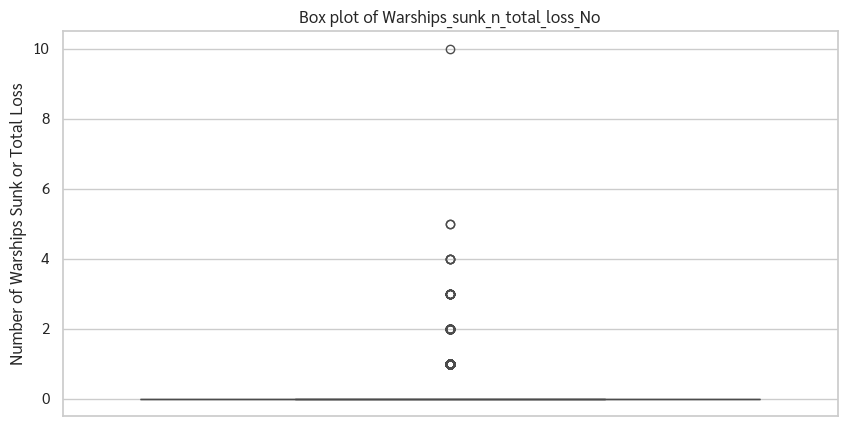

In [ ]:
plt.figure(figsize=(10, 5))
sb.boxplot(y=cleaned_uboat['Warships_sunk_n_total_loss_No'])
plt.title('Box plot of Warships_sunk_n_total_loss_No')
plt.ylabel('Number of Warships Sunk or Total Loss')
plt.show()

**สรุป**
เนื่องจากใน dataset นั้นมีค่า outliner ที่จำเป็นต่อการคำนวน (ค่าทั้งที่หมดที่ไม่ใช่ 0)ทำให้เราไม่สามารถทำ outliner ได้

#Data Preparation (After Cleansing)

## Normalization / **Standardization**

---



### การทำ Normalization  Standardization

  ใน model uboat เราเลือกใช้ Standardization โดยที่ไม่ใช่ Normalization เพราะว่า
  1. สามารถจัดการค่า Outliers ที่มีมากในชุดข้อมูลนี้ได้ - Standardization ไม่ถูกกระทบจาก Outliers (เรือดำน้ำ Ace ที่จมเรือได้เยอะเป็นพิเศษ) มากนัก ในขณะที่ Normalization จะอ่อนไหวต่อ Outliers มาก

  2. ผลลัพธ์ที่เหมาะกับการเรียนรู้ของโมเดล - Standardization แปลงข้อมูลให้มี ค่าเฉลี่ย ($\mu$) เป็น 0 และ ส่วนเบี่ยงเบนมาตรฐาน ($\sigma$) เป็น 1 ทำให้ข้อมูลมีศูนย์กลางอยู่รอบๆ 0การมี $\mu=0$ ช่วยให้ขั้นตอนวิธีที่ใช้ Gradient Descent (เช่น Logistic Regression หรือ Neural Networks) สามารถลู่เข้า (Converge) ได้เร็วขึ้นและมีประสิทธิภาพมากขึ้น
  
  3. การรักษาข้อมูลเชิงความรู้ - Standardization รักษา "รูปร่าง" เดิมของการกระจายตัวของข้อมูลไว้ได้ดีกว่า ทำให้โมเดลสามารถรับรู้และเรียนรู้ความแตกต่างระหว่างค่าต่างๆ ที่อยู่ใกล้กันในข้อมูลส่วนใหญ่ได้ชัดเจนการใช้ Normalization จะทำให้ความแตกต่างเล็กๆ น้อยๆ ในข้อมูลส่วนใหญ่ถูกบีบอัดจนหายไป (Squashing Effect) ทำให้ข้อมูลสูญเสียมิติในการทำนายไป

---



ขั้นตอนที่ 1 : การเลือก column ที่ทีผลต่อการจมซึ่งมีทั้งหมด 13  column

In [ ]:
features_to_use = [
    'Warships_sunk_n_total_loss_No', 'Warships_sunk_n_total_loss_Tons-n-GRT',
    'Warships_Damaged_No', 'Warships_Damaged_Tons-n-GRT',
    'Merchant_Ships_sunk_No', 'Merchant_Ships_sunk_GRT',
    'Merchant_Ships_damaged_No', 'Merchant_Ships_damaged_GRT',
    'Merchant_Ships_total_loss_No', 'Merchant_Ships_total_loss_GRT',
    'Patrols_Count', 'Wolfpacks_Count', 'Flotilla_Count'
]

ขั้นตอนที่ 2 : การแปลง fate event โดยที่เราจะแบ่งเป็น

  lost_fates_encoded ซึ่งประกอบด้วย Sunk,Scuttled และ Missing จากนั้นเปลี่ยนให้กลายเป็น 1

  survived_fates_encoded ซึ่งประกอบด้วย Surrendered จากนั้นเปลี่ยนให้กลายเป็น 0

  

In [ ]:
# y: สร้าง Target Binary (1=Lost, 0=Survived) โดยอิงจาก Fate_Event ที่เข้ารหัสไว้
lost_fates_encoded = [15, 12, 9]    # เช่น Sunk, Scuttled, Missing
survived_fates_encoded = [16]       # เช่น Surrendered

encode_uboat['Target'] = np.nan
encode_uboat.loc[encode_uboat['Fate_Event'].isin(lost_fates_encoded), 'Target'] = 1
encode_uboat.loc[encode_uboat['Fate_Event'].isin(survived_fates_encoded), 'Target'] = 0

std_uboat = encode_uboat.dropna(subset=['Target']) # ตัดแถวที่ไม่ใช่ Lost/Survived

ขั้นตอนที่ 3 : เตรียมข้อมูลสำหรับการทำ Standardization ซึ่งแบ่งเป็น 2 ตัวแปรนั้นคือ

X : เป็น dataframe ที่เก็บข้อมูลที่มี column ในลิสต์ features_to_use ซึ่งตัด column ที่ไม่จำเป็นออกไป

Y : เป็น dataframe ที่เก็บข้อมูลที่มี column ชื่อว่า Target เท่านั้นซึ่งมีค่า 0 และ 1

จากนั้นแบ่งข้อมูลเป็น 2 ส่วนนั้นคือ train และ test เพื่อเตรียมทำ Standardization

In [ ]:
X = std_uboat[features_to_use]
y = std_uboat['Target'].astype(int)

# แบ่งข้อมูล (Train-Test Split) - ต้องทำก่อน Scaling!
# stratify=y ช่วยให้สัดส่วน Lost/Survived ใน Train และ Test เท่ากัน
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# display(y_train)

ขั้นตอนที่ 4 : การสร้าง StandardScaler เพื่อทำ Standardization

โดยเราจะสร้าง Scaler และนำ dataframe นั้นคือ X_train เขาไปเพื่อสร้าง model จากนั้นนำไปปรับสเกลให้กลายเป็นค่ามาตรฐาน

โดยเมื่อทำเสร็จแล้วจะได้ค่า X_train_scaled และ X_test_scaled ซึ่งสำหรับการฝึกโมเดล โดยที่แต่ละค่าคือค่าที่ถูกปรับสเกลมาแล้วทำให้ทุก column มีสเกลตัวที่เท่าๆกัน

mean : ค่าเฉลี่ย

std : ส่วนเบี่ยงเบนมาตรฐาน

min : ค่าต่ำสุด

25% : ควอไทล์ที่ 1

50% : ควอไทล์ที่ 2

75% : ควอไทล์ที่ 3

max : ค่าสูงสุด

In [ ]:
# 4. สร้างและใช้ StandardScaler (Standardization)
scaler = StandardScaler()

# 4.1. "Fit" (เรียนรู้ Mean และ Std Dev) เฉพาะ X_train เท่านั้น
scaler.fit(X_train)

# 4.2. "Transform" (แปลง) ทั้ง X_train และ X_test โดยใช้ค่าที่เรียนรู้จาก X_train
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("--- การทำ Standardization (Z-score Scaling) เสร็จสมบูรณ์ ---")
print("ผลลัพธ์ที่ได้คือ X_train_scaled และ X_test_scaled\n")

# 5. ตรวจสอบผลลัพธ์
# แปลงกลับเป็น DataFrame เพื่อตรวจสอบค่าสถิติ
cleaned_uboat_pre = pd.DataFrame(X_train_scaled, columns=features_to_use)
pd.set_option('display.max_columns', None) # เพิ่มโค้ดนี้เพื่อแสดงทุกคอลัมน์
display(cleaned_uboat_pre.describe().round(2))
pd.reset_option('display.max_columns') # เพิ่มโค้ดนี้เพื่อรีเซ็ตค่ากลับ

--- การทำ Standardization (Z-score Scaling) เสร็จสมบูรณ์ ---
ผลลัพธ์ที่ได้คือ X_train_scaled และ X_test_scaled



,Warships_sunk_n_total_loss_No,Warships_sunk_n_total_loss_Tons-n-GRT,Warships_Damaged_No,Warships_Damaged_Tons-n-GRT,Merchant_Ships_sunk_No,Merchant_Ships_sunk_GRT,Merchant_Ships_damaged_No,Merchant_Ships_damaged_GRT,Merchant_Ships_total_loss_No,Merchant_Ships_total_loss_GRT,Patrols_Count,Wolfpacks_Count,Flotilla_Count
count,778.00,778.00,778.00,778.00,778.00,778.00,778.00,778.00,778.00,778.00,778.00,778.00,778.00
mean,0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,-0.00,0.00,-0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.37,-0.20,-0.21,-0.12,-0.40,-0.38,-0.38,-0.37,-0.20,-0.20,-0.85,-0.52,-1.25
25%,-0.37,-0.20,-0.21,-0.12,-0.40,-0.38,-0.38,-0.37,-0.20,-0.20,-0.78,-0.52,-0.16
50%,-0.37,-0.20,-0.21,-0.12,-0.40,-0.38,-0.38,-0.37,-0.20,-0.20,-0.30,-0.52,-0.16
75%,-0.37,-0.20,-0.21,-0.12,-0.06,-0.11,-0.38,-0.37,-0.20,-0.20,0.51,0.32,0.93
max,13.26,12.84,8.19,16.11,8.54,9.16,9.06,9.62,10.39,11.46,4.57,5.35,5.27


#**Data Visualization**


---





##**เหตุการณ์ Fate Event ของเรือต่อจำนวนเรือ**

In [ ]:
cleaned_uboat.columns

Index(['Name', 'Year', 'Type', 'Notable Commanders',
       'Warships_sunk_n_total_loss_No',
       'Warships_sunk_n_total_loss_Tons-n-GRT', 'Warships_Damaged_No',
       'Warships_Damaged_Tons-n-GRT', 'Merchant_Ships_sunk_No',
       'Merchant_Ships_sunk_GRT', 'Merchant_Ships_damaged_No',
       'Merchant_Ships_damaged_GRT', 'Merchant_Ships_total_loss_No',
       'Merchant_Ships_total_loss_GRT', 'Fate_Event', 'Fate_Date',
       'Patrols_Count', 'Wolfpacks_Count', 'Flotilla_Count', 'Last_Flotilla',
       'Fate_Event_Encoded', 'Type_Encoded', 'Last_Flotilla_Encoded'],
      dtype='object')

ส่วนนี้ไว้เเสดงว่าใน Dataset นี้มี Columns อะไรบ้าง

---

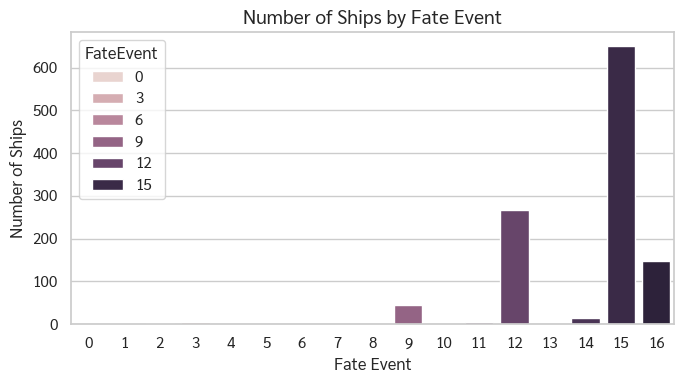

In [ ]:
Fate_Table = encode_uboat['Fate_Event'].value_counts().reset_index()
Fate_Table.columns = ['FateEvent', 'ShipCount']

# สร้าง Barplot เพื่อเเสดงจำนวนเรือโดยให้กราฟสูง 4 นิ้ว ยาว 7 นิ้ว
plt.figure(figsize=(7,4))
sb.barplot(
    x='FateEvent',
    y='ShipCount',
    hue='FateEvent',
    data=Fate_Table,
)

plt.title('Number of Ships by Fate Event', fontsize=14, fontweight='bold')
plt.xlabel('Fate Event', fontsize=12)
plt.ylabel('Number of Ships', fontsize=12)
plt.tight_layout()
plt.show()

จากที่กราฟเเสดงจะเห็นได้ว่าวิธีการหมดหน้าที่ของเรือนั้นส่วนใหญ่เกิดจากเหตุการณ์ที่ 15 หรอือก็คือการถูกจม (Sunk) นั่นเอง รองลงมาคือเหตุการณ์ที่ 16 หรือก็คือยอมเเพ้ (Surrendered) เเละตามมาด้วยเหตุการณ์ที่ 12 (Scuttled) เเละ เหตุการณ์ที่ 9 (Missing) ตามลำดับ

---

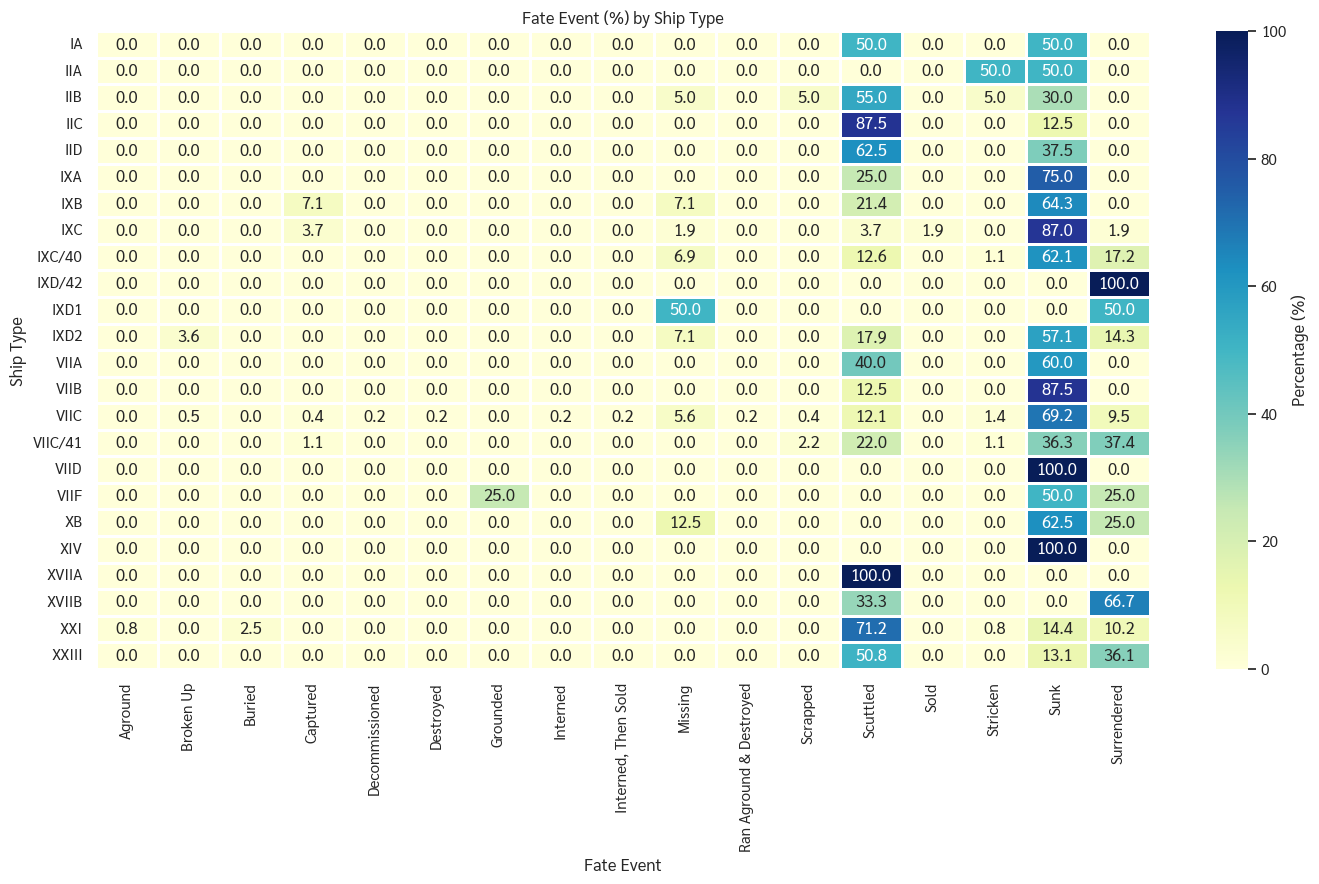

In [ ]:
percentage_table = pd.crosstab(
    cleaned_uboat['Type'],
    cleaned_uboat['Fate_Event'],
  # ตั้งให้ใช้ค่าโดยคิดเป็น 100%
    normalize='index'
) * 100

# ปัดทศนิยมให้เหลือ 1 ตำเเหน่ง
percentage_table = percentage_table.round(1)

# ตั้งขนาดของกราฟที่จะได้
fig_w = max(8, percentage_table.shape[1] * 1.0)
fig_h = max(5, percentage_table.shape[0] * 0.345)

# สร้าง heatmap
plt.figure(figsize=(fig_w, fig_h))
ax = sb.heatmap(percentage_table, annot=True, fmt=".1f",
                cmap="YlGnBu", cbar_kws={'label': 'Percentage (%)'},
                linewidths=1,linecolor='white')

plt.title('Fate Event (%) by Ship Type')
plt.xlabel('Fate Event')
plt.ylabel('Ship Type')
plt.show()

จาก Heatmap รายละเอียดของกราฟคือ
- แกน Y = Type ของเรือดำน้ำเยอรมัน (เช่น II, VIIA, VIIC, IX ฯลฯ)
- แกน X = ชะตากรรม (Fate Event) เช่น Sunk, Scuttled, Surrendered, Missing ฯลฯ
- สีเข้ม คือรุ่นนั้นมีชะตากรรมแบบนั้นมากกว่าเมื่อเทียบกับรุ่นอื่น
- สีอ่อน คือเหตุการณ์นั้นน้อยกว่าค่าเฉลี่ยของรุ่นอื่น ๆ


จากตารางนี้เเสดงให้เห็นถึง**อัตราส่วนของรุ่นของเรือเเละอัตราการจมคิดเป็น 100%**


ได้ว่าเรือในรุ่น Type VIIA และ Type VIIC มีอัตราการจมสูงสุดเทียบกับรุ่นอื่น เเละรุ่นใหม่กว่าอย่าง Type IX และ Type XXI มีสัดส่วนยอมแพ้กับอยู่รอดมากกว่า

---

##**กราฟแกน x เป็นรุ่น Y เป็นจำนวนที่ผลิต**


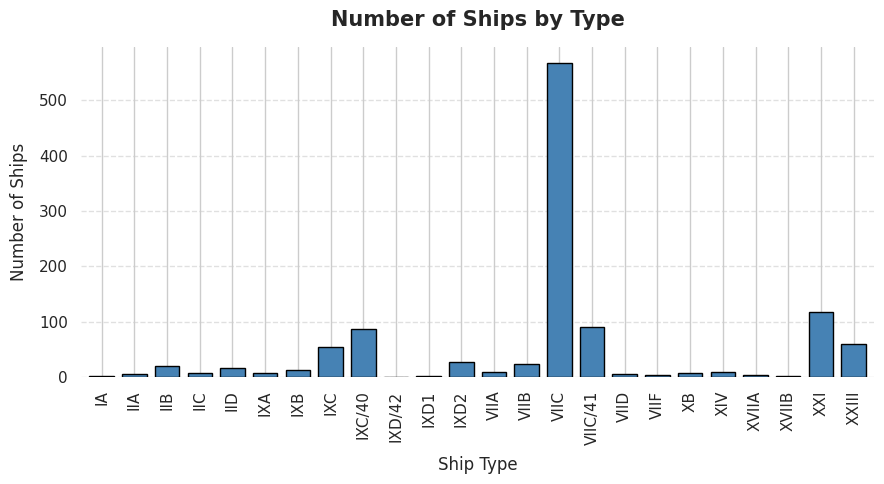

In [ ]:
# รวมจำนวนเรือตาม Type โดยไม่แยกตาม Fate Event
ship_count = cleaned_uboat['Type'].value_counts().sort_index()

# ตั้งค่าธีม seaborn
sb.set_theme(style="whitegrid")

# วาดกราฟแท่งธรรมดา
ax = ship_count.plot(
    kind='bar',
    figsize=(9,5),
    color='steelblue',
    edgecolor='black',
    width=0.75
)

# เพิ่มหัวข้อและฉลาก
plt.title('Number of Ships by Type', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Ship Type', fontsize=12, labelpad=8)
plt.ylabel('Number of Ships', fontsize=12, labelpad=8)

# ปรับกราฟให้ดูสวย
plt.grid(axis='y', linestyle='--', alpha=0.6)
sb.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


จากกราฟจะเห็นได้ว่าเรือที่ผลิตเกือบทั้งหมดจะเป็น VIIC และรองลงมาคือ XXI,IXC/40,VIIC/41 ตามลำดับ

##**กราฟแสดงความสัมพันธ์ของรุ่นกับอัตราการจม**

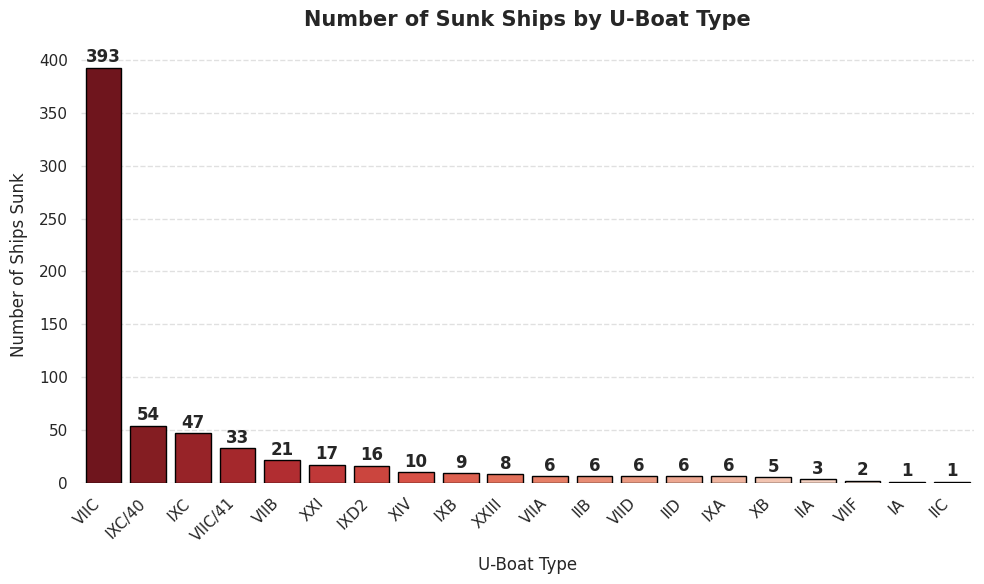

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ตั้งค่าธีมสวยๆ
sns.set_theme(style="whitegrid")
# กรองเฉพาะเรือที่จม
sunk_data = cleaned_uboat[cleaned_uboat['Fate_Event'] == 'Sunk']
# นับจำนวนเรือที่จมตามรุ่น
sunk_count = sunk_data['Type'].value_counts().reset_index()
sunk_count.columns = ['Type', 'Sunk_Count']
# วาดกราฟ
plt.figure(figsize=(10,6))
sns.barplot(
    data=sunk_count,
    x='Type', y='Sunk_Count',
    hue='Type',
    dodge=False, # ให้แท่งเป็นแท่งเดียว
    palette='Reds_r',
    legend=False,
    edgecolor='black'
)
# เพิ่ม label บนแท่ง
for i, v in enumerate(sunk_count['Sunk_Count']):
    plt.text(i, v + 5, str(int(v)), ha='center', fontweight='bold')
# ตั้งชื่อและตกแต่ง
plt.title('Number of Sunk Ships by U-Boat Type', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('U-Boat Type', fontsize=12, labelpad=8)
plt.ylabel('Number of Ships Sunk', fontsize=12, labelpad=8)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

กราฟนี้แสดงจำนวนเรือแต่ละรุ่นที่ถูกจมทั้งหมด พบว่า รุ่น Type VIIC มีจำนวนเรือจมสูงสุด ซึ่งสะท้อนถึงการที่รุ่นนี้ถูกผลิตและใช้งานมากที่สุดในสงครามโลกครั้งที่ 2 ส่วนรุ่นอื่นเช่น Type IXC, Type VIIB มีจำนวนการจมน้อยกว่า

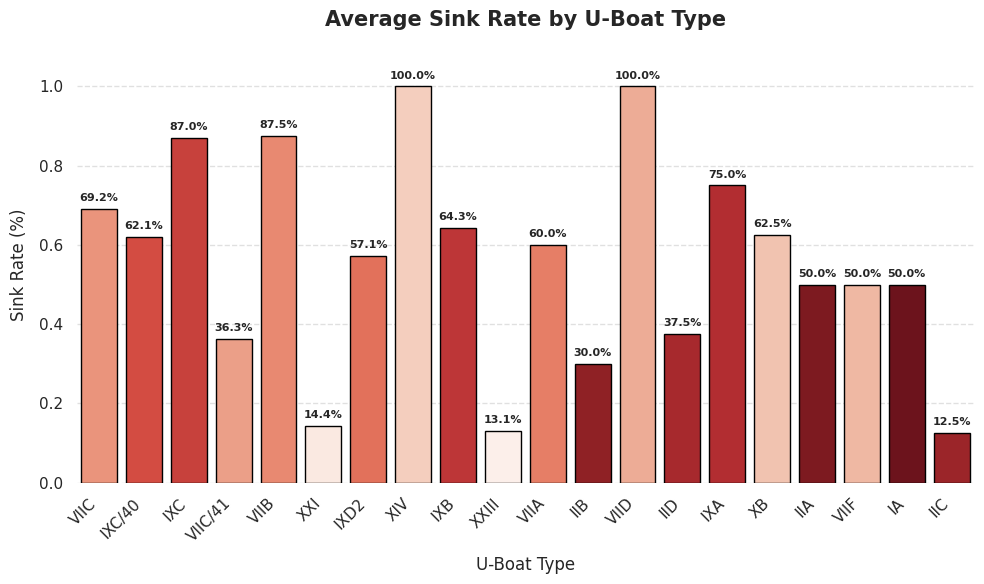

In [ ]:
# นับจำนวนเรือทั้งหมดแต่ละรุ่น
total_by_type = cleaned_uboat.groupby('Type').size().reset_index(name='Total')
# นับจำนวนเรือที่จมในแต่ละรุ่น
sunk_by_type = (
    cleaned_uboat[cleaned_uboat['Fate_Event'] == 'Sunk']
    .groupby('Type')
    .size()
    .reset_index(name='Sunk_Count')
)
# รวมตารางเพื่อคำนวณอัตราการจม
sink_rate = pd.merge(total_by_type, sunk_by_type, on='Type', how='left').fillna(0)
sink_rate['Sink_Rate'] = sink_rate['Sunk_Count'] / sink_rate['Total']
# เรียงลำดับรุ่นให้เหมือนกราฟแรก
order = sunk_count['Type']
# วาดกราฟ
plt.figure(figsize=(10,6))
sns.barplot(
    data=sink_rate,
    x='Type', y='Sink_Rate',
    hue='Type', palette='Reds_r',
    dodge=False, legend=False, edgecolor='black',
    order=order
)
# เพิ่ม label แสดงเปอร์เซ็นต์
for i, v in enumerate(sink_rate.set_index('Type').loc[order]['Sink_Rate']):
    plt.text(i, v + 0.02, f"{v*100:.1f}%", ha='center', fontweight='bold',fontsize=8)
# ตั้งชื่อและตกแต่ง
plt.title('Average Sink Rate by U-Boat Type', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('U-Boat Type', fontsize=12, labelpad=8)
plt.ylabel('Sink Rate (%)', fontsize=12, labelpad=8)
plt.ylim(0, 1.1)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

แสดง “อัตราการจมเฉลี่ย” ของแต่ละรุ่น ซึ่งคิดจากสัดส่วนระหว่างเรือที่จมต่อจำนวนเรือทั้งหมด พบว่า บางรุ่นมีอัตราการจมถึง 100% หมายความว่า “เรือทุกลำของรุ่นนั้นถูกทำลาย”
ในขณะที่รุ่นใหม่กว่าอย่าง Type XXI มีอัตราการจมต่ำมาก สะท้อนถึงการพัฒนาเทคโนโลยีและยุทธวิธีที่ดีขึ้น

## กราฟที่แสดงจำนวนเรือดำน้ำ U-boat รุ่นต่างๆที่ถูกผลิตต่อปี

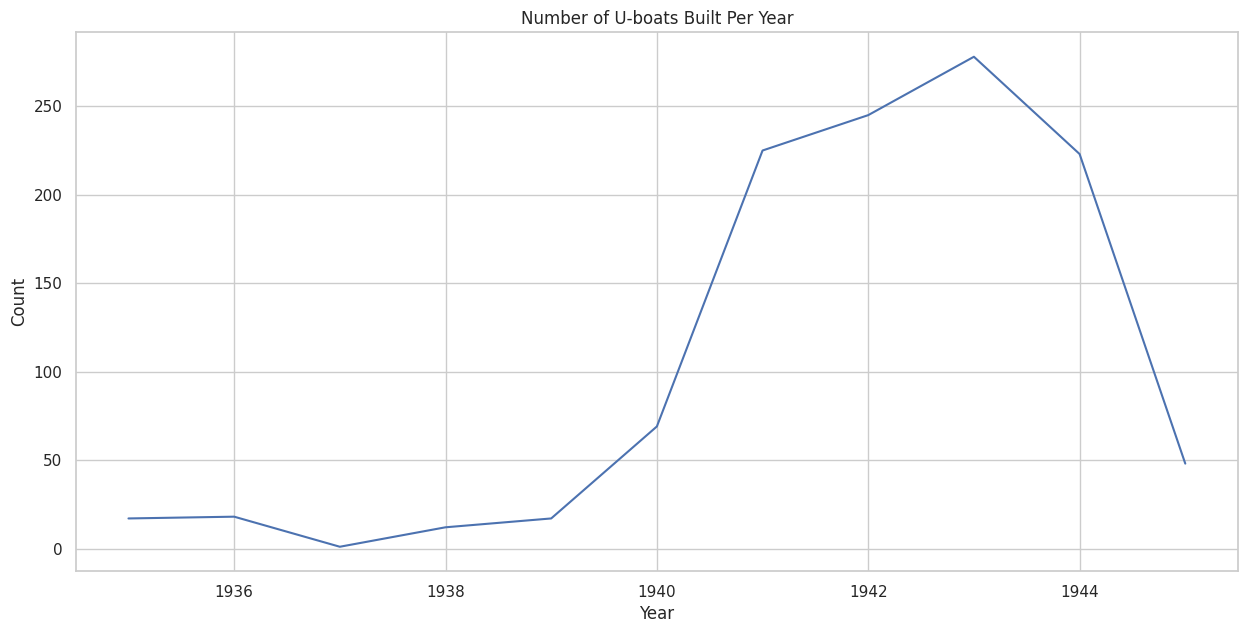

In [ ]:
#สร้าง series ที่แสดงปีกับจำนวนเรือดำน้ำที่สร้าง
uboat_count_by_year = cleaned_uboat['Year'].value_counts().sort_index()

# สร้างกราฟที่มีแกน x คือ index ของ uboat_count_by_year นั้นคือปี และ y คือจำนวนที่ผลิต
plt.figure(figsize=(15, 7))
sb.lineplot(x=uboat_count_by_year.index, y=uboat_count_by_year.values)
plt.title('Number of U-boats Built Per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.grid(True)
plt.show()

รายละเอียดของกราฟคือ
- แกน X = ปีที่สร้างเรือ
- แกน Y = จำนวนเรือที่ถูกสร้าง


จากตารางนี้เเสดงให้เห็นถึง**อัตราส่วนของรุ่นของเรือเเละอัตราการจมคิดเป็น 100%**

พบว่าแนวโน้มการสร้างเพิ่มขึ้นอย่างรวดเร็วตั้งแต่ปี 1938-1940 จนถึงจุดสูงสุดในปี 1943 ซึ่งเป็นช่วงกลางของสงครามโลกครั้งที่ 2 ก่อนจะลดลงอย่างมากในช่วงปี 1944–1945 อันเป็นช่วงท้ายสงคราม


แนวโน้มนี้สะท้อนถึงบริบททางยุทธศาสตร์ของเยอรมันที่เร่งสร้างเรือเพื่อรบในมหาสมุทรแอตแลนติก

---

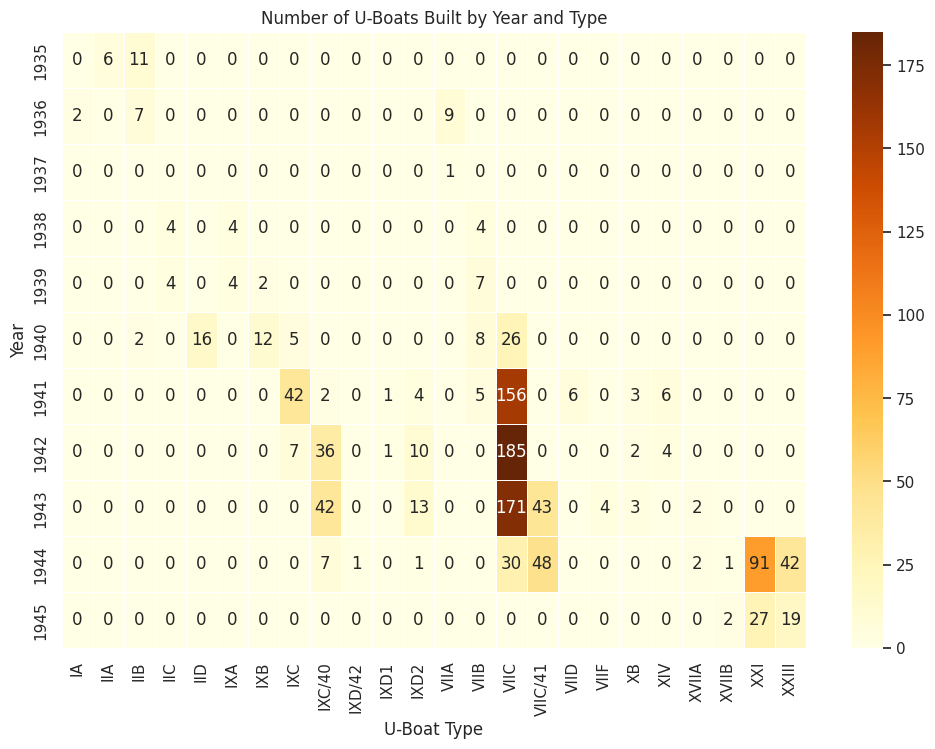

In [ ]:
# Pivot table: ปี x รุ่น -> จำนวนเรือ
year_type = cleaned_uboat.pivot_table(
    index='Year',
    columns='Type',
    aggfunc='size',
    fill_value=0
)

plt.figure(figsize=(12, 8))
sns.heatmap(
    year_type,
    cmap="YlOrBr",
    annot=True,
    fmt="d",
    linewidths=0.5
)
plt.title('Number of U-Boats Built by Year and Type')
plt.xlabel('U-Boat Type')
plt.ylabel('Year')
plt.show()


จาก Heatmap รายละเอียดของกราฟคือ
- แกน X แสดงรุ่นของเรือ เช่น IIA, VIIB, VIIC, IXC ฯลฯ
- แกน Y แสดงปีที่สร้าง
- สีเข้ม คือจำนวนเรือที่ถูกสร้างในปีนั้นมาก

จากตารางนี้เเสดงให้เห็นถึง**อัตราส่วนของรุ่นของเรือเเละอัตราการสร้างคิดเป็น 100%**

จะเห็นว่า Type VII โดยเฉพาะรุ่น VIIC ถูกผลิตจำนวนมากในช่วงปี 1941–1943
นี่คือช่วงที่กองทัพเรือเยอรมันทุ่มกำลังเข้าสงครามใต้น้ำเต็มที่ เรือรุ่นนี้จึงมีอัตราการจมสูงสุดใน dataset เพราะถูกใช้มากที่สุดในแนวรบ

---

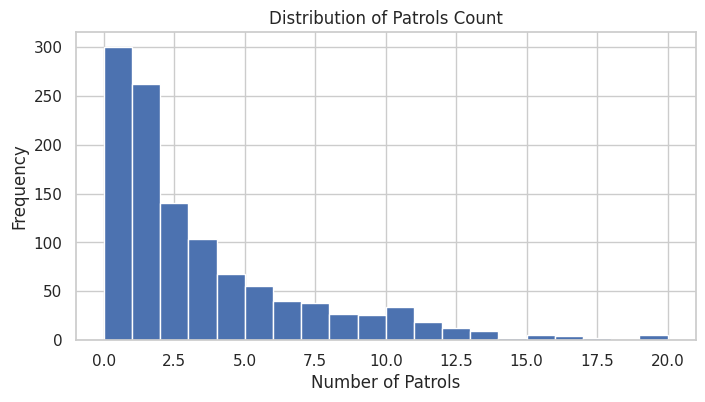

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(cleaned_uboat['Patrols_Count'].dropna(), bins=20)
plt.title('Distribution of Patrols Count')
plt.xlabel('Number of Patrols')
plt.ylabel('Frequency')
plt.show()

รายละเอียดของกราฟคือ
- แกน X = จำนวนครั้งที่เรือออกปฏิบัติการ
- แกน Y = จำนวนเรือที่มีจำนวนครั้งออกลาดตระเวน

จากกราฟจำนวนครั้งในการลาดตระเวน พบว่า

เรือส่วนใหญ่ของกองทัพเยอรมันออกปฏิบัติการเพียงไม่กี่ครั้งก่อนสิ้นสุดภารกิจ โดยมีเพียงส่วนน้อยที่ปฏิบัติการมากกว่า 10 ครั้งขึ้นไป
ซึ่งอาจสะท้อนถึงโอกาสการจมหรือถูกจำกัดการใช้งานในช่วงสงคราม

---

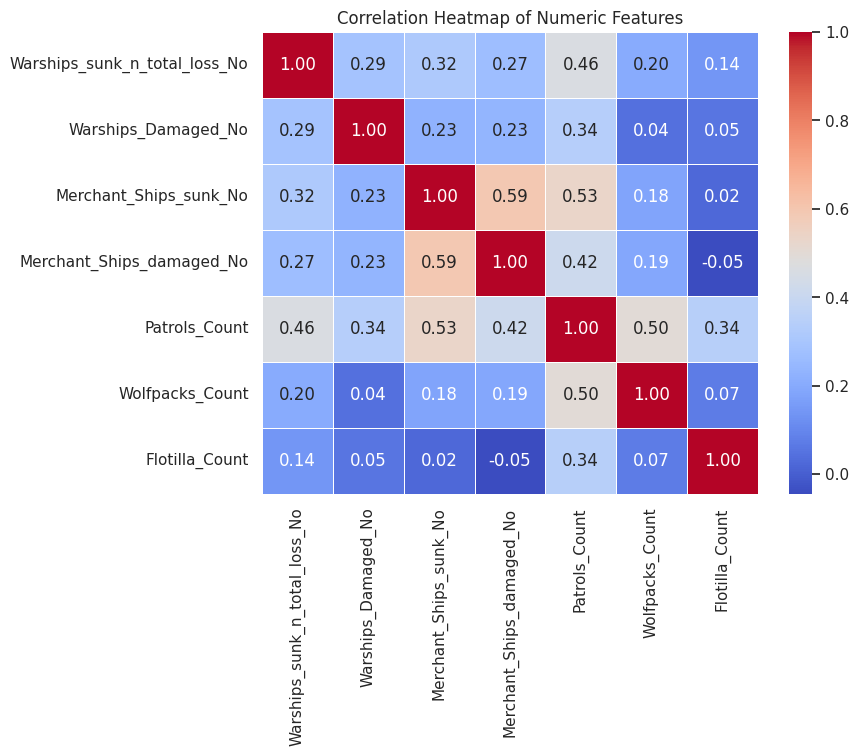

In [ ]:
numeric_cols = [
    'Warships_sunk_n_total_loss_No', 'Warships_Damaged_No',
    'Merchant_Ships_sunk_No', 'Merchant_Ships_damaged_No',
    'Patrols_Count', 'Wolfpacks_Count', 'Flotilla_Count'
]

corr_matrix = cleaned_uboat[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()


กราฟนี้เป็น Heatmap ของค่า Correlation (ค่าสหสัมพันธ์) ระหว่างตัวแปรเชิงตัวเลขทั้งหมดในชุดข้อมูล เรียงตาลำดับ

* จำนวนเรือรบที่จมทั้งหมด

* จำนวนเรือรบที่เสียหาย

* จำนวนเรือสินค้าที่จมทั้งหมด

* จำนวนเรือสินค้าที่เสียหาย

* จำนวนครั้งในการลาดตระเวน

* จำนวนกลุ่ม Wolfpack ที่เข้าร่วม

* จำนวนกองเรือที่สังกัด

ค่าสีในช่องแต่ละช่องหมายถึง “ระดับความสัมพันธ์เชิงเส้น” ระหว่างตัวแปร 2 ตัว

* **สีแดง** คือความสัมพันธ์ที่ค่ามากขึ้นด้วยกัน

* **สีฟ้า** คือความสัมพันธ์ที่ค่าหนึ่งมาก อีกค่าลดลง

* **สีอ่อน** คือความสัมพันธ์ต่ำหรือแทบไม่มี

---

# **Classification Model ⛴**



```
# This is formatted as code
```

## **Algorithm Comparison**

 1. Test Harness: กำลังเปรียบเทียบ 7 โมเดล...
ผลการประเมิน (Accuracy) จาก 10-Fold Cross-Validation:

LR: 0.862488 (0.007865)
LDA: 0.862488 (0.007865)
KNN: 0.853497 (0.024309)
CART: 0.832884 (0.023119)
NB: 0.340509 (0.049099)
SVM: 0.866334 (0.006040)
RF: 0.856011 (0.015244)

 2. Select Best Model: เปรียบเทียบประสิทธิภาพโมเดล


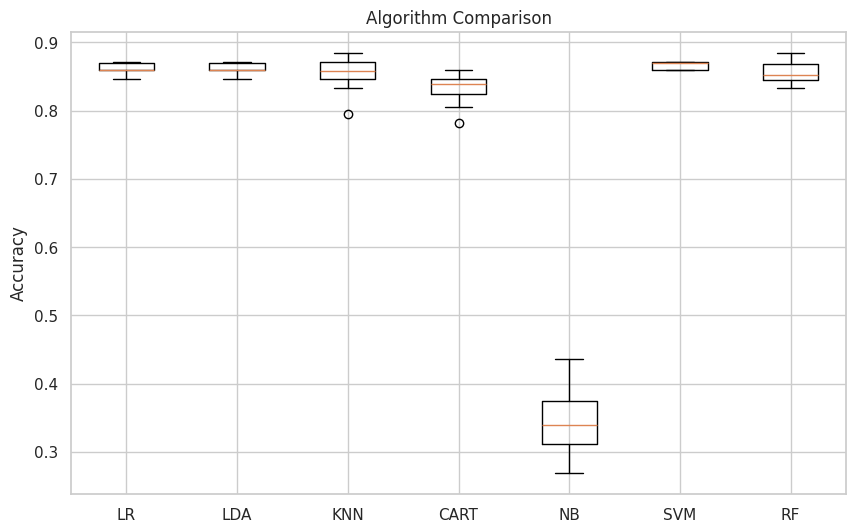

In [ ]:
print("==================================================")
print(" 1. Test Harness: กำลังเปรียบเทียบ 7 โมเดล...")
print("==================================================")

#2. สร้าง List ของโมเดลที่จะทดสอบ

models = []
models.append(('LR', LogisticRegression(solver='liblinear')))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier(random_state=42)))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC(gamma='auto', random_state=42)))
models.append(('RF', RandomForestClassifier(random_state=42)))

#3. ประเมินผลแต่ละโมเดลด้วย 10-Fold Cross-Validation

results = []
names = []
print("ผลการประเมิน (Accuracy) จาก 10-Fold Cross-Validation:\n")
for name, model in models:

    # StratifiedKFold จะช่วยแบ่งข้อมูลโดยคงสัดส่วนของคลาส 'จม'/'รอด' ไว้ในแต่ละ Fold
    kfold = StratifiedKFold(n_splits=10, random_state=1, shuffle=True)

    # เราจะประเมินโมเดลบน X_train_scaled และ Y_train
    cv_results = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring='accuracy')

    results.append(cv_results)
    names.append(name)
    print('%s: %f (%f)' % (name, cv_results.mean(), cv_results.std()))

print("\n==================================================")
print(" 2. Select Best Model: เปรียบเทียบประสิทธิภาพโมเดล")
print("==================================================")

# 4. เปรียบเทียบผลลัพธ์ด้วย Box Plot
plt.figure(figsize=(10, 6))
plt.boxplot(results, tick_labels=names) # Use tick_labels instead of labels
plt.title('Algorithm Comparison')
plt.ylabel('Accuracy')
plt.show()

--- สรุปผล --- <br>
จากกราฟ boxplot ที่เปรียบเทียบค่า Accuracy ของแต่ละโมเดล จะเห็นได้ว่าโมเดลที่มี **ค่า Accuracy เฉลี่ย (mean)** สูงที่สุด และมี **การกระจายตัวของค่า (variance หรือช่วงภายในกล่อง)** แคบที่สุด ถือเป็นโมเดลที่มีทั้ง **ความแม่นยำสูงและความเสถียรดี**  



```
# This is formatted as code
```

## การเตรียมข้อมูลก่อนการสร้างโมเดล


```
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)
```



เป็นการเตรียมข้อมูลเบื้องต้นก่อนนำไปสร้างโมเดล โดยแบ่งข้อมูลออกเป็นชุดฝึก (Train set) และชุดทดสอบ (Test set)
ในสัดส่วน 80:20 โดยคงสัดส่วนของคลาสเท่าเดิม (stratify)

จากนั้นใช้ **StandardScaler** เพื่อปรับสเกลข้อมูลของแต่ละตัวแปรให้มีค่าเฉลี่ย (mean) เท่ากับ 0
และส่วนเบี่ยงเบนมาตรฐาน (standard deviation) เท่ากับ 1 เพื่อให้ทุกตัวแปรอยู่ในระดับสเกลเดียวกัน
ซึ่งช่วยให้โมเดลเรียนรู้ได้มีประสิทธิภาพมากขึ้น โดยเฉพาะโมเดลที่อ่อนไหวต่อขนาดของข้อมูล เช่น KNN
การทำ **fit_transform()** จะกระทำเฉพาะกับชุดฝึก (train) เพื่อคำนวณค่า mean และ std
ส่วนชุดทดสอบ (test) จะใช้เพียง **transform()** ด้วยค่าพารามิเตอร์เดียวกัน
เพื่อหลีกเลี่ยงปัญหา **data leakage** หรือการที่ข้อมูลทดสอบรั่วเข้าสู่กระบวนการเรียนรู้ของโมเดล

สุดท้าย แปลงข้อมูลที่ผ่านการปรับสเกลแล้วกลับมาอยู่ในรูปแบบ DataFrame
เพื่อให้ง่ายต่อการตรวจสอบชื่อคอลัมน์และใช้งานต่อในขั้นตอนถัดไป

In [ ]:
# สร้าง label สำหรับการจม
war_fate = ["Sunk", "Destroyed", "Missing", "Ran Aground & Destroyed", "Scuttled"]
cleaned_uboat["Was_Sunk"] = cleaned_uboat["Fate_Event"].isin(war_fate).astype(int)

# เลือก features
features = [
    "Year", "Type", "Patrols_Count", "Wolfpacks_Count", "Last_Flotilla",
    "Warships_sunk_n_total_loss_No", "Warships_Damaged_No",
    "Merchant_Ships_sunk_No", "Merchant_Ships_damaged_No"
]

# ใช้ค่าของคอลัมน์ 'Type' และ 'Last_Flotilla' ที่ถูกแปลงจากข้อความเป็นตัวเลข (encode) แล้วจาก encode_uboat
X = encode_uboat[features]
y = cleaned_uboat["Was_Sunk"]

เป็นการเตรียมข้อมูลเพื่อทำนายว่าเรือดำน้ำจะจมหรือไม่ โดยสร้างคอลัมน์ Was_Sunk เพื่อระบุสถานะการจมของเรือ (1 = จม, 0 = ไม่จม) เนื่องจากคอลัมน์ Fate_Event ในชุดข้อมูลนี้มีหลายประเภทและมีความไม่สม่ำเสมอของข้อมูล จึงต้องจัดกลุ่มเหตุการณ์ที่เกี่ยวข้องกับการจมให้เป็นหมวดเดียวกันก่อนนำไปใช้สร้างโมเดลทำนาย

## **Random Forest Model**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

model_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=3,
    class_weight='balanced_subsample',
    random_state=42
)

model_rf.fit(X_train_scaled_df, y_train)
y_pred_RF = model_rf.predict(X_test_scaled_df)

print(classification_report(y_test, y_pred_RF, target_names=['รอด (0)', 'จม (1)'], zero_division=0))

              precision    recall  f1-score   support

     รอด (0)       0.45      0.76      0.56        38
      จม (1)       0.95      0.81      0.87       193

    accuracy                           0.81       231
   macro avg       0.70      0.79      0.72       231
weighted avg       0.86      0.81      0.82       231



โมเดลนี้ใช้ **RandomForestClassifier** ซึ่งเป็นการรวมผลลัพธ์จากต้นไม้หลายต้น (Decision Trees)
โดยการสุ่มเลือก feature และข้อมูลบางส่วนในแต่ละต้น เพื่อลดการเอนเอียง (bias) และเพิ่มความแม่นยำโดยรวม
Random Forest เป็นหนึ่งในโมเดลที่ให้ความเสถียรและแม่นยำสูงในหลายกรณี

**การตีความค่าผลลัพธ์**

| ค่าชี้วัด     | ความหมาย                                                      |
| ------------- | ------------------------------------------------------------- |
| **Precision** | ความแม่นยำของการทำนายว่าข้อมูลอยู่ในคลาสนั้น ๆ                |
| **Recall**    | ความสามารถในการทำนายข้อมูลจริงของคลาสนั้น ๆ ได้ครบถ้วนเพียงใด |
| **F1-score**  | ค่ากลางระหว่าง precision และ recall เพื่อวัดประสิทธิภาพโดยรวม |
| **Support**   | จำนวนตัวอย่างจริงในแต่ละคลาส                                  |

**ผลการทดสอบ**

* คลาส “จม (1)” มี **precision = 0.95**, **recall = 0.81**, **f1-score = 0.87**
  → โมเดลสามารถตรวจจับกรณี “จม” ได้ดีทั้งความแม่นและความครอบคลุม
* คลาส “รอด (0)” มี **precision = 0.45**, **recall = 0.76**, **f1-score = 0.56**
  → มีแนวโน้มที่จะทำนายผิดบ้างในกลุ่ม “รอด”
* ค่า **accuracy = 0.81** หมายถึงโมเดลทำนายถูกประมาณ 81% ของทั้งหมด
* ค่า **macro avg F1 = 0.70** และ **weighted avg F1 = 0.86**
  บ่งบอกว่าโมเดลมีสมดุลและความแม่นยำโดยรวมดี

โดยรวม Random Forest ให้ผลลัพธ์ที่มีความเสถียรและแม่นยำสูง
เหมาะสำหรับข้อมูลที่มีความซับซ้อนหรือมีความไม่สมดุลระหว่างคลาส


## **DecisionTreeClassifier**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)


model_cart = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=42
)

model_cart.fit(X_train_scaled_df, y_train)
y_pred_CART = model_cart.predict(X_test_scaled_df)

print(classification_report(y_test, y_pred_CART, target_names=['รอด (0)', 'จม (1)'], zero_division=0))

              precision    recall  f1-score   support

     รอด (0)       0.36      0.71      0.48        38
      จม (1)       0.93      0.75      0.83       193

    accuracy                           0.74       231
   macro avg       0.64      0.73      0.65       231
weighted avg       0.84      0.74      0.77       231



โมเดลนี้ใช้ **DecisionTreeClassifier** ซึ่งเป็นอัลกอริทึมแบบ “ต้นไม้ตัดสินใจ” (Decision Tree)
โดยทำการแบ่งข้อมูลตามเงื่อนไขของตัวแปรต่าง ๆ ทีละขั้น เพื่อแยกกลุ่มผลลัพธ์ออกจากกันอย่างชัดเจน
ช่วยให้ตีความได้ง่ายเพราะสามารถมองเห็นเส้นทางการตัดสินใจของโมเดล

**การตีความค่าผลลัพธ์**

| ค่าชี้วัด     | ความหมาย                                                                                    |
| ------------- | ------------------------------------------------------------------------------------------- |
| **Precision** | ความแม่นยำของการทำนายในแต่ละคลาส (โมเดลทำนายว่า “จม” แล้วจมจริงกี่เปอร์เซ็นต์)              |
| **Recall**    | ความสามารถในการจับข้อมูลจริงของแต่ละคลาส (ในข้อมูลที่ “จมจริง” โมเดลทำนายถูกกี่เปอร์เซ็นต์) |
| **F1-score**  | ค่ากลางระหว่าง precision และ recall แสดงความสมดุลระหว่างความแม่นและความครอบคลุม             |
| **Support**   | จำนวนตัวอย่างจริงในแต่ละคลาส                                                                |

**ผลการทดสอบ**

* คลาส “จม (1)” มีค่า **precision = 0.93**, **recall = 0.75**, **f1-score = 0.83**
  → โมเดลทำนายกรณีจมได้ดี แต่ยังพลาดบางกรณี
* คลาส “รอด (0)” มี **recall = 0.71**, แต่ precision ค่อนข้างต่ำ (0.36)
  → แสดงว่าโมเดลยังแยกเรือที่ “รอด” ได้ไม่ดีนัก
* ค่า **accuracy = 0.74** หมายถึงโมเดลทำนายถูกประมาณ 74% ของข้อมูลทั้งหมด
* ค่า **macro avg F1 = 0.64** และ **weighted avg F1 = 0.84**
  บ่งบอกว่าโมเดลมีความแม่นระดับปานกลาง โดยได้รับอิทธิพลจากคลาสที่มีจำนวนมากกว่า

โดยรวม Decision Tree ให้ผลลัพธ์พอใช้ แต่ยังมีแนวโน้ม overfit และแสดง bias ต่อคลาสที่มีข้อมูลมากกว่า



## **KNeighborsClassifier Model**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

model_knn = KNeighborsClassifier(
    n_neighbors=5,
    n_jobs=-1
)

# Fit with DataFrame X_train_scaled_df
model_knn.fit(X_train_scaled_df, y_train)
# Predict with DataFrame X_test_scaled_df
y_pred_KNN = model_knn.predict(X_test_scaled_df)

print(classification_report(y_test, y_pred_KNN, target_names=['รอด (0)', 'จม (1)'], zero_division=0))

              precision    recall  f1-score   support

     รอด (0)       0.75      0.32      0.44        38
      จม (1)       0.88      0.98      0.93       193

    accuracy                           0.87       231
   macro avg       0.81      0.65      0.69       231
weighted avg       0.86      0.87      0.85       231



โมเดลนี้ใช้หลักการ “**ดูเพื่อนบ้านที่ใกล้ที่สุด**” เพื่อทำนายผลลัพธ์
โดยจะนำข้อมูลใหม่ไปเทียบกับข้อมูลฝึกที่อยู่ใกล้ที่สุด k ตัว แล้วให้คลาสที่พบมากสุดเป็นคำตอบ
ในที่นี้ใช้ `n_neighbors = 5` หมายถึงพิจารณาเพื่อนบ้าน 5 ตัวอย่าง

**การตีความค่าผลลัพธ์**

| ค่าชี้วัด     | ความหมาย                                                |
| ------------- | ------------------------------------------------------- |
| **Precision** | โมเดลทำนายว่าข้อมูลเป็นคลาสใด แล้วถูกต้องกี่เปอร์เซ็นต์ |
| **Recall**    | โมเดลสามารถตรวจจับข้อมูลจริงของคลาสนั้นได้มากน้อยแค่ไหน |
| **F1-score**  | ค่ากลางระหว่าง precision และ recall                     |
| **Support**   | จำนวนข้อมูลจริงในคลาสนั้น ๆ                             |

**ผลการทดสอบ**

* คลาส “จม (1)” มีค่า **precision = 0.88**, **recall = 0.98**, **f1-score = 0.93**
  → โมเดลสามารถทำนายกรณีจมได้แม่นยำมาก
* คลาส “รอด (0)” มี **recall = 0.32**, **f1-score = 0.44**
  → หมายถึงโมเดลพลาดการทำนายเรือที่ “รอด” ไปจำนวนมาก
* ค่า **accuracy = 0.87** แสดงว่าโมเดลโดยรวมแม่นยำสูง
* ค่า **macro avg F1 = 0.81**, **weighted avg F1 = 0.86**
  แสดงว่าโมเดลมีสมดุลดีในภาพรวม แต่ยัง bias ไปทางคลาส “จม”

โดยรวม KNN ทำงานได้ดีเมื่อข้อมูลมีสเกลที่เหมาะสม และมีความแม่นยำสูงในกรณีคลาสใหญ่
แต่ประสิทธิภาพลดลงเมื่อข้อมูลไม่สมดุลระหว่างคลาส



## **การเปรียบเทียบประสิทธิภาพของโมเดล**

In [ ]:
!wget -q https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf
font_manager.fontManager.addfont('Sarabun-Regular.ttf')
plt.rcParams['font.family'] = 'Sarabun'
plt.rcParams['axes.unicode_minus'] = False

def full_report_df(y_true, y_pred, labels=[0,1], target_names=None, zero_division=0, digits=3):
    if target_names is None:
        target_names = [str(l) for l in labels]

    r = classification_report(
        y_true, y_pred, labels=labels, target_names=target_names,
        output_dict=True, zero_division=zero_division
    )

    rows = {}
    for lab, tname in zip(labels, target_names):
        val = r.get(tname, r.get(str(lab), {}))
        rows[tname] = {
            'precision': round(float(val.get('precision', np.nan)), digits),
            'recall': round(float(val.get('recall', np.nan)), digits),
            'f1-score': round(float(val.get('f1-score', np.nan)), digits),
            'support': int(val.get('support', 0))
        }

    acc = r.get('accuracy', None)
    rows['accuracy'] = {
        'precision': np.nan,
        'recall': np.nan,
        'f1-score': round(float(acc), digits) if acc is not None else np.nan,
        'support': int(len(y_true))
    }

    for avg_name in ['macro avg', 'weighted avg']:
        val = r.get(avg_name, {})
        rows[avg_name] = {
            'precision': round(float(val.get('precision', np.nan)), digits),
            'recall': round(float(val.get('recall', np.nan)), digits),
            'f1-score': round(float(val.get('f1-score', np.nan)), digits),
            'support': int(val.get('support', 0)) if 'support' in val else 0
        }

    return pd.DataFrame(rows).T[['precision','recall','f1-score','support']]

def make_multi_df(dfs, model_names):
    pieces = []
    for df, name in zip(dfs, model_names):
        df_cols = pd.concat({name: df}, axis=1)
        pieces.append(df_cols)
    return pd.concat(pieces, axis=1)

def plot_metric_by_class(combined_df, models, classes, metric='f1-score',
                         figsize=(7,4), ylim=(0,1)):
    metric_df = pd.DataFrame({
        m: combined_df[m][metric].reindex(classes).values
        for m in models
    }, index=classes)

    fig, ax = plt.subplots(figsize=figsize)
    metric_df.plot(kind='bar', ax=ax)

    ax.set_title(f'{metric.capitalize()} by class and model')
    ax.set_ylabel(metric.capitalize())
    ax.set_ylim(*ylim)
    ax.tick_params(axis='x', rotation=0)

    ax.legend(title='Model', loc='center left', bbox_to_anchor=(1.0, 0.5))

    plt.tight_layout()
    plt.show()

In [ ]:
labels = [0, 1]
target_names = ['รอด (0)', 'จม (1)']
models = ['RF', 'CART', 'KNN']

# ใช้ prediction ที่คุณมีอยู่
df_rf = full_report_df(y_test, y_pred_RF, labels=labels, target_names=target_names)
df_cart = full_report_df(y_test, y_pred_CART, labels=labels, target_names=target_names)
df_knn = full_report_df(y_test, y_pred_KNN, labels=labels, target_names=target_names)

# รวมทั้งหมด
combined = make_multi_df([df_rf, df_cart, df_knn], models)
display(combined)


RF                              CART                  \
             precision recall f1-score support precision recall f1-score   
รอด (0)          0.446  0.763    0.563    38.0     0.360  0.711    0.478   
จม (1)           0.946  0.813    0.875   193.0     0.929  0.751    0.831   
accuracy           NaN    NaN    0.805   231.0       NaN    NaN    0.745   
macro avg        0.696  0.788    0.719   231.0     0.645  0.731    0.654   
weighted avg     0.864  0.805    0.823   231.0     0.836  0.745    0.773   

                           KNN                          
             support precision recall f1-score support  
รอด (0)         38.0     0.750  0.316    0.444    38.0  
จม (1)         193.0     0.879  0.979    0.926   193.0  
accuracy       231.0       NaN    NaN    0.870   231.0  
macro avg      231.0     0.815  0.648    0.685   231.0  
weighted avg   231.0     0.858  0.870    0.847   231.0

### สรุปผลการเปรียบเทียบประสิทธิภาพโมเดล (By Class and Model)

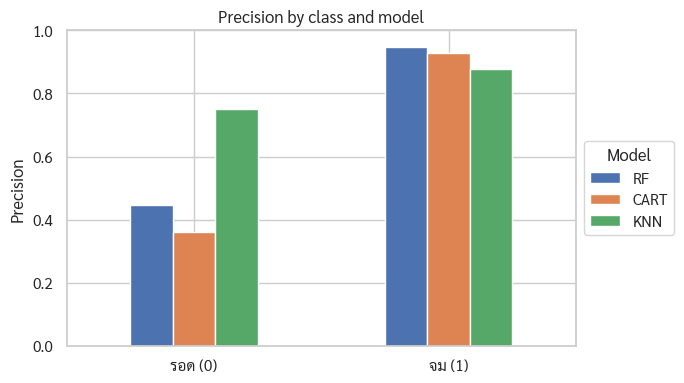

In [ ]:
class_rows = target_names  # ['รอด (0)', 'จม (1)']
plot_metric_by_class(combined, models, class_rows, metric='precision')

จากกราฟ Precision จะเห็นว่า  
- **RF** และ **CART** มีค่า precision ของคลาส “จม (1)” ใกล้เคียงกัน (สูงกว่า 0.9)  
  แสดงว่าเมื่อโมเดลทำนายว่า “จม” มักถูกต้องเกือบทั้งหมด  
- ส่วนค่า precision ของคลาส “รอด (0)” ต่ำกว่า โดยเฉพาะ CART (~0.35) แสดงว่ามีการทำนายผิดเป็น “รอด” มาก  
- **KNN** มี precision ของ “รอด (0)” สูงที่สุด (~0.7) หมายความว่าโมเดลมีความแม่นยำขึ้นในการทำนายเรือที่ “รอดจริง”

สรุป:  
> RF และ CART แม่นยำมากในคลาส “จม”  
> ส่วน KNN มีความแม่นยำสูงกว่าในคลาส “รอด”


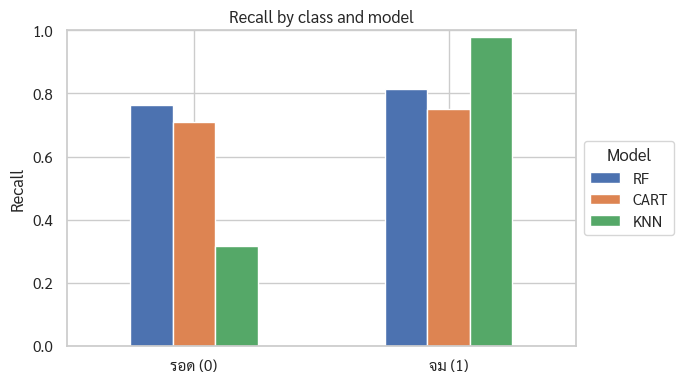

In [ ]:
plot_metric_by_class(combined, models, class_rows, metric='recall')

จากกราฟ Recall พบว่า  
- **KNN** มี recall ของคลาส “จม (1)” สูงที่สุด (~0.97)  
  แสดงว่าโมเดลแทบไม่พลาดในการตรวจจับเรือที่ “จมจริง”  
- แต่ recall ของคลาส “รอด (0)” ต่ำมาก (~0.37) หมายถึงโมเดลมักทำนาย “จม” เกินจริง  
- **RF** มี recall ที่ค่อนข้างสมดุล (รอด = 0.79, จม = 0.81)  
  ขณะที่ **CART** มีค่าใกล้เคียงกันแต่ต่ำกว่าเล็กน้อย

สรุป:  
> KNN เด่นในความสามารถจับคลาส “จม” ได้เกือบทั้งหมด แต่ทำนาย “รอด” ผิดบ่อย  
> RF มีความสมดุลมากที่สุดระหว่างสองคลาส


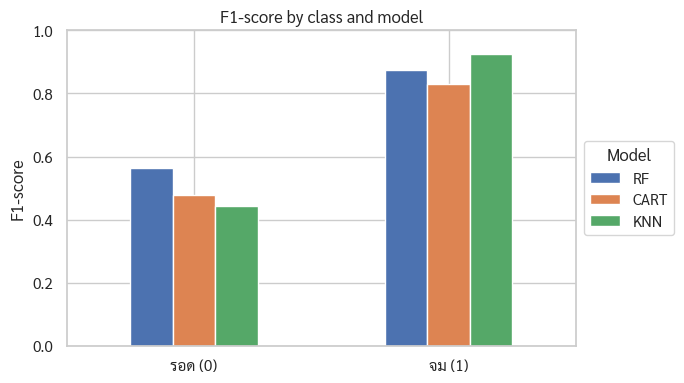

In [ ]:
plot_metric_by_class(combined, models, class_rows, metric='f1-score')

จากกราฟ F1-score  
- **RF** ให้ค่า F1 สูงทั้งสองคลาส แสดงถึงความสมดุลระหว่าง precision และ recall  
- **CART** มีค่าลดลงเล็กน้อยทั้งสองคลาส โดยเฉพาะ “รอด (0)”  
- **KNN** ให้ค่า F1 ของ จม (1)” สูงสุด (0.9) แต่ของ “รอด (0) ต่ำสุด (0.45)  
  สะท้อนว่าโมเดลนี้เอนเอียงไปทางการทำนาย “จม” มากกว่า

สรุป:  
> RF มีความสมดุลดีที่สุดในทุกคลาส  
> KNN เด่นในคลาส “จม” แต่ด้อยในคลาส “รอด”  
> CART อยู่ระดับกลางของทั้งสองด้าน

**จากกราฟทั้งสาม (Precision, Recall และ F1-score) จะเห็นว่าโมเดลทั้งสามมีลักษณะการทำงานที่แตกต่างกันอย่างชัดเจน**

- **Random Forest (RF)** มีสมดุลระหว่าง precision, recall และ f1-score ของทั้งสองคลาส  
  แสดงให้เห็นว่าโมเดลสามารถจำแนก “รอด (0)” และ “จม (1)” ได้ดีโดยไม่เอนเอียงไปด้านใดด้านหนึ่ง  

- **CART** ให้ผลอยู่ในระดับกลาง โดยค่า precision และ recall ต่ำกว่า RF เล็กน้อย  
  โดยเฉพาะในคลาส “รอด (0)” ที่มีแนวโน้มถูกทำนายผิดมากกว่า  

- **KNN** มีค่า recall ของคลาส “จม (1)” สูงที่สุด  
  หมายความว่าโมเดลแทบไม่พลาดการตรวจจับเรือที่ “จมจริง”  
  แต่ recall ของคลาส “รอด (0)” ต่ำมาก แสดงว่าโมเดลมักทำนาย “จม” เกินจริง  

**โดยสรุป**
> **RF** เป็นโมเดลที่มีความสมดุลดีที่สุด  
> **KNN** เด่นในความสามารถตรวจจับเรือที่ “จมจริง”  
> ส่วน **CART** ให้ผลลัพธ์ระดับปานกลางแต่ยังคงแนวโน้มใกล้เคียงกับ RF


### สรุปภาพรวมการเปรียบเทียบ Confusion Matrix


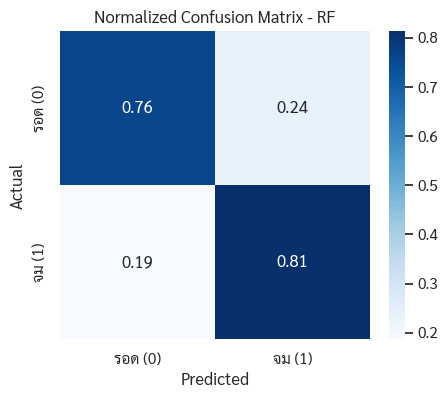

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_RF, normalize='true')
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['รอด (0)', 'จม (1)'],
            yticklabels=['รอด (0)', 'จม (1)'])
plt.title('Normalized Confusion Matrix - RF')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


**สรุปผล Confusion Matrix – RF**

จากกราฟจะเห็นว่าโมเดล **Random Forest** สามารถจำแนกคลาสได้ค่อนข้างสมดุล  
- จำแนก “รอด (0)” ถูกต้อง **76%** และ “จม (1)” ถูกต้อง **81%**  
- มีการทำนายผิดพลาดทั้งสองฝั่งใกล้เคียงกัน (ประมาณ 20%)  

แสดงว่า RF มีความสามารถในการจำแนกทั้งสองคลาสได้ดี  
โดยไม่เอนเอียงไปทางใดทางหนึ่งมากนัก เหมาะกับกรณีที่ต้องการ **ความสมดุลระหว่าง recall และ precision**


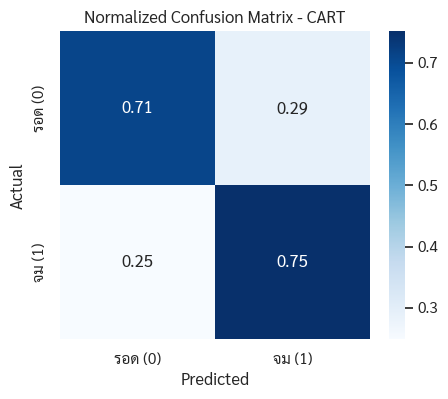

In [ ]:
cm_cart = confusion_matrix(y_test, y_pred_CART, normalize='true')
plt.figure(figsize=(5, 4))
sns.heatmap(cm_cart, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['รอด (0)', 'จม (1)'],
            yticklabels=['รอด (0)', 'จม (1)'])
plt.title('Normalized Confusion Matrix - CART')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


**สรุปผล Confusion Matrix – CART**

โมเดล **CART** ให้ผลใกล้เคียงกับ RF แต่ความแม่นยำลดลงเล็กน้อย  
- จำแนก “รอด (0)” ถูกต้อง **71%** และ “จม (1)” ถูกต้อง **75%**  
- สัดส่วนการทำนายผิดในคลาส “รอด” มากกว่า RF เล็กน้อย  

สรุปว่า CART ยังมีแนวโน้ม **พลาดทำนายคลาส “รอด”** มากกว่าคลาส “จม”  
ทำให้โดยรวมแม่นยำรองลงมาจาก RF


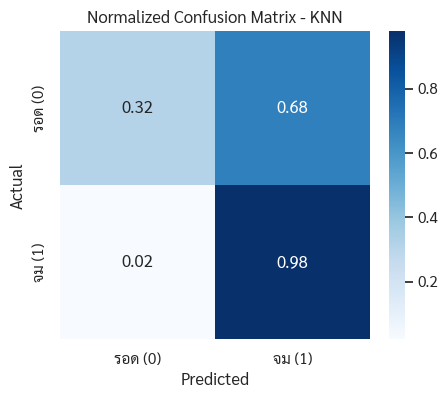

In [ ]:
cm_knn = confusion_matrix(y_test, y_pred_KNN, normalize='true')
plt.figure(figsize=(5, 4))
sns.heatmap(cm_knn, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['รอด (0)', 'จม (1)'],
            yticklabels=['รอด (0)', 'จม (1)'])
plt.title('Normalized Confusion Matrix - KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


**สรุปผล Confusion Matrix – KNN**

โมเดล **KNN** มีลักษณะเด่นชัดว่า bias ไปทางคลาส “จม”  
- จำแนก “จม (1)” ถูกต้องสูงถึง **98%**  
- แต่จำแนก “รอด (0)” ได้ถูกเพียง **32%** เท่านั้น  

หมายความว่า KNN **เกือบไม่พลาดการทำนาย “จมจริง”**  
แต่แลกมาด้วยการ **ทำนายผิดว่า “จม” ทั้งที่จริง “รอด”** ในหลายกรณี  


**เมื่อเปรียบเทียบผลของทั้งสามโมเดลจะเห็นแนวโน้มดังนี้**

- **Random Forest (RF)**  
  มีความสมดุลระหว่างการทำนาย “รอด” และ “จม” มากที่สุด  
  ค่า accuracy โดยรวมอยู่ในระดับดี และอัตราการทำนายผิดพลาดของแต่ละคลาสใกล้เคียงกัน  
  เหมาะกับกรณีที่ต้องการ **ผลลัพธ์ที่แม่นยำและสมดุล**

- **CART**  
  แม้จะให้ผลใกล้เคียงกับ RF แต่ความแม่นยำต่ำกว่าเล็กน้อย  
  โดยเฉพาะในคลาส “รอด (0)” ที่มีแนวโน้มทำนายผิดมากกว่า  
  จึงถือว่าเป็นโมเดลที่อยู่ระดับกลางของกลุ่ม

- **KNN**  
  มีจุดเด่นในด้าน **การตรวจจับเรือที่ “จมจริง” ได้แทบทั้งหมด (recall สูงมาก)**  
  แต่มีข้อเสียคือทำนายผิดในคลาส “รอด” จำนวนมาก  
  แสดงถึงการ **เอนเอียงไปทางคลาส “จม”**  

**โดยสรุป**
> **RF** ให้ความสมดุลดีที่สุดระหว่างสองคลาส  
> **KNN** เหมาะในกรณีที่ต้องการลดการพลาดคลาส “จม”  
> ส่วน **CART** ให้ผลลัพธ์ปานกลางแต่ยังคงมีแนวโน้มคล้าย RF

### สรุปการเปรียบเทียบภาพรวมของประสิทธิภาพโมเดลทั้งหมด

,Model,Accuracy,Macro Avg F1,Weighted Avg F1
0,RF,0.805,0.719,0.823
1,CART,0.745,0.654,0.773
2,KNN,0.870,0.685,0.847


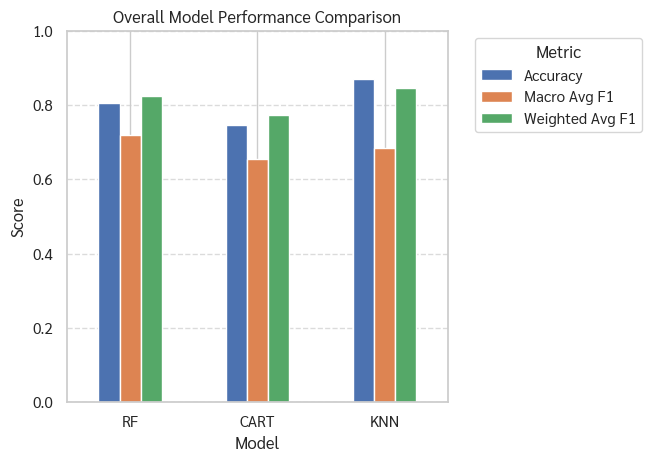

In [ ]:
# ใช้ prediction ที่มีอยู่
labels = [0, 1]
target_names = ['รอด (0)', 'จม (1)']
models = ['RF', 'CART', 'KNN']

df_rf = full_report_df(y_test, y_pred_RF, labels=labels, target_names=target_names)
df_cart = full_report_df(y_test, y_pred_CART, labels=labels, target_names=target_names)
df_knn = full_report_df(y_test, y_pred_KNN, labels=labels, target_names=target_names)

# สร้าง DataFrame สรุปจากผลการทำนายจริง
data = {
    'Model': models,
    'Accuracy': [df_rf.loc['accuracy', 'f1-score'], df_cart.loc['accuracy', 'f1-score'], df_knn.loc['accuracy', 'f1-score']],
    'Macro Avg F1': [df_rf.loc['macro avg', 'f1-score'], df_cart.loc['macro avg', 'f1-score'], df_knn.loc['macro avg', 'f1-score']],
    'Weighted Avg F1': [df_rf.loc['weighted avg', 'f1-score'], df_cart.loc['weighted avg', 'f1-score'], df_knn.loc['weighted avg', 'f1-score']]
}
summary_df = pd.DataFrame(data)


# แสดงตารางสรุป
display(summary_df)

# สร้างกราฟเปรียบเทียบ
plt.figure(figsize=(8, 5))
ax = summary_df.set_index('Model')[['Accuracy', 'Macro Avg F1', 'Weighted Avg F1']].plot(kind='bar', ax=plt.gca())
plt.title('Overall Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1.0)

ax.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.xticks(rotation=0)
plt.show()

จากตารางและกราฟ “Overall Model Performance Comparison”  
สามารถสรุปผลการทำงานของโมเดลทั้งสามได้ดังนี้

- **KNN** มีค่า Accuracy สูงที่สุดที่ **0.870** และ Weighted Avg F1 เท่ากับ **0.847**  
  แสดงให้เห็นว่าโมเดลนี้มีความแม่นยำโดยรวมดีที่สุด แม้ค่า Macro Avg F1 (0.680)  
  จะต่ำกว่า RF เล็กน้อย ซึ่งอาจเกิดจากความเอนเอียงไปยังคลาสที่มีจำนวนมากกว่า

- **Random Forest (RF)** มีประสิทธิภาพโดยรวมดีเป็นอันดับสอง  
  ด้วย Accuracy **0.805** และ Weighted Avg F1 **0.823**  
  จุดเด่นคือมีค่า Macro Avg F1 สูงสุด (**0.719**) สะท้อนว่าโมเดลนี้ให้สมดุลระหว่างสองคลาสได้ดีกว่า KNN

- **CART (Decision Tree)** มีผลลัพธ์ต่ำสุดในทั้งสามโมเดล  
  โดย Accuracy เท่ากับ **0.745** และ Weighted Avg F1 เท่ากับ **0.773**  
  แต่ยังคงแสดงแนวโน้มที่สอดคล้องกับโมเดลอื่นในลักษณะการจำแนกผล

**โดยสรุป**  
> **KNN** ให้ความแม่นยำโดยรวมดีที่สุด  
> **RF** ให้ความสมดุลระหว่างคลาสดีที่สุด  
> **CART** มีประสิทธิภาพน้อยกว่าแต่ยังอยู่ในระดับใช้งานได้

# Permutation Importance

In [ ]:
def permutation_importance_df(model, X_test, y_test, model_name, n_repeats=20):
    result = permutation_importance(model, X_test, y_test,
                                    n_repeats=n_repeats,
                                    random_state=42)

    df = pd.DataFrame({
        "feature": X_test.columns,
        "importance": result.importances_mean,
        "std": result.importances_std
    }).sort_values("importance", ascending=False)

    df["model"] = model_name
    return df


# ╠╠ Random Forest
pi_rf = permutation_importance_df(model_rf, X_test_scaled_df, y_test, "Random Forest")

# ╠╠ CART (Decision Tree)
pi_cart = permutation_importance_df(model_cart, X_test_scaled_df, y_test, "CART")

# ╠╠ KNN
pi_knn = permutation_importance_df(model_knn, X_test_scaled_df, y_test, "KNN")

pi_all = pd.concat([pi_rf, pi_cart, pi_knn], ignore_index=True)
pi_all

,feature,importance,std,model
0,Type,0.105628,0.013920,Random Forest
1,Patrols_Count,0.098052,0.012862,Random Forest
2,Last_Flotilla,0.038961,0.020397,Random Forest
3,Year,0.030736,0.018156,Random Forest
4,Merchant_Ships_sunk_No,0.027922,0.013093,Random Forest
5,Merchant_Ships_damaged_No,0.005411,0.002695,Random Forest
6,Wolfpacks_Count,0.003247,0.018103,Random Forest
7,Warships_Damaged_No,-0.000433,0.001299,Random Forest
8,Warships_sunk_n_total_loss_No,-0.003896,0.003325,Random Forest
9,Year,0.080736,0.025839,CART


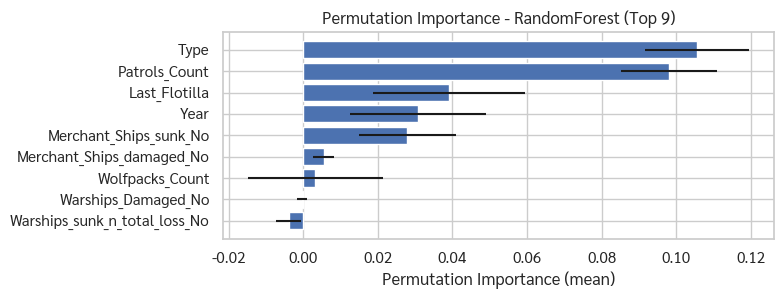

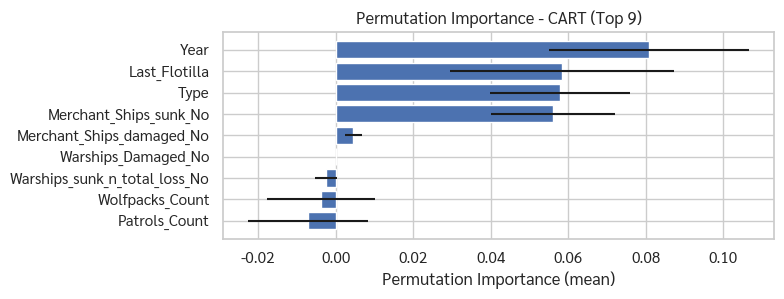

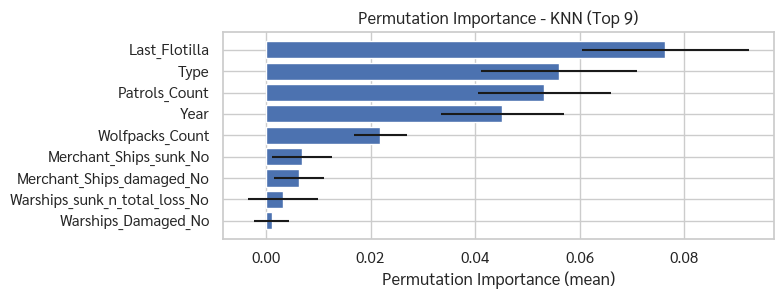

In [ ]:
def plot_horizontal(df, model_name, topn=15):
    top = df.sort_values('importance', ascending=False).head(topn).iloc[::-1]
    plt.figure(figsize=(8, max(3, 0.35*len(top))))
    plt.barh(top['feature'], top['importance'], xerr=top['std'])
    plt.xlabel("Permutation Importance (mean)")
    plt.title(f"Permutation Importance - {model_name} (Top {len(top)})")
    plt.tight_layout()
    #OUTPUT_DIR is not defined, so commenting out savefig for now.
    #fn = f"{OUTPUT_DIR}/pi_{model_name}.png"
    #plt.savefig(fn)
    plt.show()
    #print("Saved:", fn)

plot_horizontal(pi_rf, "RandomForest", topn=12)
plot_horizontal(pi_cart, "CART", topn=12)
plot_horizontal(pi_knn, "KNN", topn=12)